# **EDA Project(Myntra Product Analysis - Men Formal Shirts)**

# 1.Problem Definition:
### A customer wants to buy fashion products from Myntra such as clothing, shoes, and accessories. While exploring different categories, the customer finds thousands of products with similar styles and features but large price differences.
### Some products are highly priced due to brand value, discounts, ratings, or fashion trends, while others offer similar quality at lower prices.
### This creates confusion for customers in choosing the best value-for-money product

# Business Questions(Optional)

* Is paying more for branded fashion products actually worth it?
* Do higher discounts significantly influence product purchases?
* Are higher customer ratings linked to higher product prices?
* Which product features genuinely increase fashion product prices?
* Which brands provide the best value for money?
* Do premium brands always offer better quality products?

# 2. Business Problem Statement

Customers shopping on Myntra often face difficulty in identifying the best products because thousands of similar fashion items are available with different prices, discounts, ratings, and brand values.

Many products appear similar in style and features, but their prices vary significantly, creating confusion for customers while making purchasing decisions.

The goal of this project is to perform web scraping and Exploratory Data Analysis (EDA) on Myntra product data to identify pricing trends, brand performance, discount patterns, and customer preferences that help in finding value-for-money products.


# Project Objectives

* Collect product data from Myntra using web scraping techniques
* Analyze product prices, discounts, ratings, and brand performance
* Identify factors that influence product pricing on Myntra
* Compare products to find value-for-money fashion items
* Perform data cleaning and Exploratory Data Analysis (EDA)
* Visualize product trends using charts and graphs
* Generate meaningful business insights from the scraped data
* Understand customer preferences based on ratings and reviews
* Identify top-performing brands and product categories
* Help customers make better purchasing decisions using data analysis


In [10]:
!pip install selenium

In [110]:
import pandas as pd
import numpy as np
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
import matplotlib.pyplot as plt
import seaborn as sns
import time
import re
import warnings
warnings.filterwarnings('ignore')

In [111]:
options  = Options()

In [112]:
driver = webdriver.Chrome(options = options)

In [113]:
driver

<selenium.webdriver.chrome.webdriver.WebDriver (session="218c2da8cf21882b0c188d4967bcfcfc")>

In [114]:
driver.maximize_window()

In [115]:
url = "https://www.myntra.com/men-formal-shirts"

In [116]:
driver.get(url)

In [117]:
time.sleep(5)

In [118]:
driver.maximize_window()

In [119]:
for page in range(1, 12):

    print(f"Page {page} Details")

    driver.get(f"https://www.myntra.com/men-formal-shirts?p={page}")

    time.sleep(5)

    brand = driver.find_elements(By.CLASS_NAME, "product-brand")
    product = driver.find_elements(By.CLASS_NAME,"product-product")
    price = driver.find_elements(By.CLASS_NAME,"product-discountedPrice")
    old_price = driver.find_elements(By.CLASS_NAME,"product-strike")
    discount = driver.find_elements(By.CLASS_NAME,"product-discountPercentage")
   
    print("Brands found:", len(brand))
    print("Products found:", len(product))
    print("Prices found:", len(price))
    print("Old Prices found:", len(old_price))
    print("Discounts found:", len(discount))

Page 1 Details
Brands found: 50
Products found: 50
Prices found: 50
Old Prices found: 50
Discounts found: 50
Page 2 Details
Brands found: 50
Products found: 50
Prices found: 50
Old Prices found: 50
Discounts found: 50
Page 3 Details
Brands found: 50
Products found: 50
Prices found: 50
Old Prices found: 50
Discounts found: 50
Page 4 Details
Brands found: 50
Products found: 50
Prices found: 50
Old Prices found: 50
Discounts found: 50
Page 5 Details
Brands found: 50
Products found: 50
Prices found: 50
Old Prices found: 50
Discounts found: 50
Page 6 Details
Brands found: 50
Products found: 50
Prices found: 50
Old Prices found: 50
Discounts found: 50
Page 7 Details
Brands found: 50
Products found: 50
Prices found: 49
Old Prices found: 49
Discounts found: 49
Page 8 Details
Brands found: 50
Products found: 50
Prices found: 50
Old Prices found: 50
Discounts found: 50
Page 9 Details
Brands found: 50
Products found: 50
Prices found: 50
Old Prices found: 50
Discounts found: 50
Page 10 Details
Bra

In [121]:
brands = []
products = []
prices = []
old_prices = []
discounts = []
ratings = []
reviews = []


for page in range(1, 12):

    driver.get(f"https://www.myntra.com/men-formal-shirts?p={page}")

    time.sleep(5)

    for tag in driver.find_elements(By.CLASS_NAME, "product-brand"):
        text = tag.text
        b = re.findall(r'.+', text)
        brands.extend(b)

    for tag in driver.find_elements(By.CLASS_NAME, "product-product"):
        text = tag.text
        p = re.findall(r'.+', text)
        products.extend(p)

    for tag in driver.find_elements(By.CLASS_NAME, "product-discountedPrice"):
        prices.append(tag.text)

    for tag in driver.find_elements(By.CLASS_NAME, "product-strike"):
        old_prices.append(tag.text)

    for tag in driver.find_elements(By.CLASS_NAME, "product-discountPercentage"):
        discounts.append(tag.text)

    for tag in driver.find_elements(By.CLASS_NAME,"product-ratingsContainer"):
        text = tag.text

        if "|" in text:
            rating,review = text.split("|")
            ratings.append(rating.strip() + "★")
            reviews.append(review.strip())


    print(f"Page {page} Scraped")

print("Brands:", brands)
print("-" * 153)
print("Products:", products)
print("-" * 153)
print("Prices:",prices)
print("-" * 153)
print("Old Prices:",old_prices)
print("-" * 153)
print("Discount Prices:",discounts)
print("-" * 153)
print("Ratings:",ratings)
print("-" * 153)
print("Reviews",reviews)

print("-" * 153)

print("Total Brands:",len(brands))
print("Total Products:",len(products))
print("Total Prices",len(prices))
print("Total Old Prices:",len(old_prices))
print("Total Discounts:",len(discounts))
print("Total Ratings:",len(discounts))
print("Total Reviews:",len(discounts))

Page 1 Scraped
Page 2 Scraped
Page 3 Scraped
Page 4 Scraped
Page 5 Scraped
Page 6 Scraped
Page 7 Scraped
Page 8 Scraped
Page 9 Scraped
Page 10 Scraped
Page 11 Scraped
Brands: ['HIGHLANDER', 'HIGHLANDER', 'Arrow', 'MISCHIEF MONKEY', 'Blackberrys', 'INVICTUS', 'Thomas Scott', 'AD By Arvind', 'Raymond', 'Manspire', 'AD By Arvind', 'Park Avenue', 'Thomas Scott', 'Arrow', 'MISCHIEF MONKEY', 'MISCHIEF MONKEY', 'AD By Arvind', 'AD By Arvind', 'CAHOOT', 'AD By Arvind', 'Arrow', 'Park Avenue', 'HIGHLANDER', 'Manspire', 'FUNKY RICH', 'AD By Arvind', 'Manspire', 'Park Avenue', 'Mufti', 'Raymond', 'FUNKY RICH', 'Arrow', 'Raymond', 'INVICTUS', 'Arrow', 'Arrow', 'FUNKY RICH', 'Arrow', 'Park Avenue', 'Raymond', 'Arrow', 'Marks & Spencer', 'FUNKY RICH', 'Arrow', 'Mufti', 'URBANICE', 'Arrow', 'INVICTUS', 'FUNKY RICH', 'Arrow', 'HIGHLANDER', 'Arrow', 'MISCHIEF MONKEY', 'HIGHLANDER', 'INVICTUS', 'Thomas Scott', 'AD By Arvind', 'Raymond', 'Manspire', 'AD By Arvind', 'Park Avenue', 'Thomas Scott', 'Arrow',

In [123]:
from itertools import zip_longest

data = list(zip(brands,products,prices,old_prices,discounts,ratings,reviews))
data

[('HIGHLANDER',
  'Slim Fit Opaque Casual Shirt',
  'Rs. 479',
  'Rs. 1599',
  '(70% OFF)',
  '4.2★',
  '208.7k'),
 ('HIGHLANDER',
  'Slim Fit Opaque Casual Shirt',
  'Rs. 463',
  'Rs. 1599',
  '(71% OFF)',
  '4.2★',
  '208.7k'),
 ('Arrow',
  'Cotton Slim Fit Formal Shirt',
  'Rs. 740',
  'Rs. 1899',
  '(61% OFF)',
  '4.7★',
  '33'),
 ('MISCHIEF MONKEY',
  'Men Solid Cotton Formal Shirt',
  'Rs. 584',
  'Rs. 2088',
  '(Rs. 1504 OFF)',
  '4.2★',
  '10.5k'),
 ('Blackberrys',
  'Opaque Formal Shirt',
  'Rs. 1027',
  'Rs. 2055',
  '(50% OFF)',
  '4.1★',
  '307'),
 ('INVICTUS',
  'Easy Care Men Formal Shirt',
  'Rs. 559',
  'Rs. 1199',
  '(53% OFF)',
  '4★',
  '9.9k'),
 ('Thomas Scott',
  'Formal Shirt',
  'Rs. 809',
  'Rs. 3999',
  '(80% OFF)',
  '4.3★',
  '1.4k'),
 ('AD By Arvind',
  'Formal Shirt',
  'Rs. 927',
  'Rs. 1599',
  '(42% OFF)',
  '4.3★',
  '842'),
 ('Raymond',
  'Pure Cotton Formal Shirt',
  'Rs. 938',
  'Rs. 1999',
  '(53% OFF)',
  '3.7★',
  '2.1k'),
 ('Manspire',
  'Casual 

In [124]:
df = pd.DataFrame(data,columns=['Brands','Products','Prices','Old_Prices','Discounts','Ratings','Reviews'])
df

,Brands,Products,Prices,Old_Prices,Discounts,Ratings,Reviews
0,HIGHLANDER,Slim Fit Opaque Casual Shirt,Rs. 479,Rs. 1599,(70% OFF),4.2★,208.7k
1,HIGHLANDER,Slim Fit Opaque Casual Shirt,Rs. 463,Rs. 1599,(71% OFF),4.2★,208.7k
2,Arrow,Cotton Slim Fit Formal Shirt,Rs. 740,Rs. 1899,(61% OFF),4.7★,33
3,MISCHIEF MONKEY,Men Solid Cotton Formal Shirt,Rs. 584,Rs. 2088,(Rs. 1504 OFF),4.2★,10.5k
4,Blackberrys,Opaque Formal Shirt,Rs. 1027,Rs. 2055,(50% OFF),4.1★,307
...,...,...,...,...,...,...,...
445,INVICTUS,Slim Fit Cotton Formal Shirt,Rs. 769,Rs. 2199,(65% OFF),4.1★,166
446,Arrow,Pure Cotton Formal Shirt,Rs. 558,Rs. 1499,(63% OFF),4.5★,473
447,FUNKY RICH,Men Shirt,Rs. 443,Rs. 1199,(63% OFF),4.1★,2.6k
448,INVICTUS,Regular Fit Formal Shirt,Rs. 699,Rs. 1999,(65% OFF),4.4★,182


In [125]:
df.head()

,Brands,Products,Prices,Old_Prices,Discounts,Ratings,Reviews
0,HIGHLANDER,Slim Fit Opaque Casual Shirt,Rs. 479,Rs. 1599,(70% OFF),4.2★,208.7k
1,HIGHLANDER,Slim Fit Opaque Casual Shirt,Rs. 463,Rs. 1599,(71% OFF),4.2★,208.7k
2,Arrow,Cotton Slim Fit Formal Shirt,Rs. 740,Rs. 1899,(61% OFF),4.7★,33
3,MISCHIEF MONKEY,Men Solid Cotton Formal Shirt,Rs. 584,Rs. 2088,(Rs. 1504 OFF),4.2★,10.5k
4,Blackberrys,Opaque Formal Shirt,Rs. 1027,Rs. 2055,(50% OFF),4.1★,307


In [126]:
df.isnull().sum()

Brands        0
Products      0
Prices        0
Old_Prices    0
Discounts     0
Ratings       0
Reviews       0
dtype: int64

In [127]:
df.duplicated().sum()

np.int64(9)

In [128]:
df.drop_duplicates(inplace= True)

In [129]:
df

,Brands,Products,Prices,Old_Prices,Discounts,Ratings,Reviews
0,HIGHLANDER,Slim Fit Opaque Casual Shirt,Rs. 479,Rs. 1599,(70% OFF),4.2★,208.7k
1,HIGHLANDER,Slim Fit Opaque Casual Shirt,Rs. 463,Rs. 1599,(71% OFF),4.2★,208.7k
2,Arrow,Cotton Slim Fit Formal Shirt,Rs. 740,Rs. 1899,(61% OFF),4.7★,33
3,MISCHIEF MONKEY,Men Solid Cotton Formal Shirt,Rs. 584,Rs. 2088,(Rs. 1504 OFF),4.2★,10.5k
4,Blackberrys,Opaque Formal Shirt,Rs. 1027,Rs. 2055,(50% OFF),4.1★,307
...,...,...,...,...,...,...,...
445,INVICTUS,Slim Fit Cotton Formal Shirt,Rs. 769,Rs. 2199,(65% OFF),4.1★,166
446,Arrow,Pure Cotton Formal Shirt,Rs. 558,Rs. 1499,(63% OFF),4.5★,473
447,FUNKY RICH,Men Shirt,Rs. 443,Rs. 1199,(63% OFF),4.1★,2.6k
448,INVICTUS,Regular Fit Formal Shirt,Rs. 699,Rs. 1999,(65% OFF),4.4★,182


In [16]:
df["Prices"] = df["Prices"].str.extract(r'(\d+)')
df["Old_Prices"] = df["Old_Prices"].str.extract(r'(\d+)')
df["Discounts"] = df["Discounts"].str.extract(r'(\d+)')
df["Ratings"] = df["Ratings"].str.extract(r'([\d.]+)')
df["Reviews"] = df["Reviews"].str.extract(r'([\d.]+)')

In [17]:
df['Prices'] = pd.to_numeric(df['Prices'])
df["Old_Prices"] = pd.to_numeric(df["Old_Prices"])
df["Discounts"] = pd.to_numeric(df["Discounts"])
df["Ratings"] = pd.to_numeric(df["Ratings"])
df["Reviews"] = pd.to_numeric(df["Reviews"])

In [18]:
df

,Brands,Products,Prices,Old_Prices,Discounts,Ratings,Reviews
0,HIGHLANDER,Slim Fit Opaque Casual Shirt,479,1599,70,4.2,208.8
1,HIGHLANDER,Slim Fit Opaque Casual Shirt,463,1599,71,4.2,208.8
2,Park Avenue,Slim Fit Formal Shirt,492,1699,71,4.4,728.0
3,Raymond,Slim Fit Cotton Formal Shirt,587,2099,72,4.3,335.0
4,Blackberrys,Opaque Formal Shirt,1027,2055,50,4.1,307.0
...,...,...,...,...,...,...,...
414,Park Avenue,Slim Fit Cotton Formal Shirt,990,2199,55,4.3,842.0
415,Arrow,Regular Fit Formal Shirt,779,1999,61,4.4,226.0
416,Turtle,Slim Fit Casual Shirt,1189,1699,30,4.4,24.0
417,CAHOOT,Casual Shirt,725,2199,67,4.4,258.0


In [19]:
df.info()  # It is used to get a quick summary of the dataset structure.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 419 entries, 0 to 418
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Brands      419 non-null    object 
 1   Products    419 non-null    object 
 2   Prices      419 non-null    int64  
 3   Old_Prices  419 non-null    int64  
 4   Discounts   419 non-null    int64  
 5   Ratings     419 non-null    float64
 6   Reviews     419 non-null    float64
dtypes: float64(2), int64(3), object(2)
memory usage: 23.0+ KB


In [20]:
df.shape

(419, 7)

In [21]:
df.head()  # It shows the first 5 rows of the dataset

,Brands,Products,Prices,Old_Prices,Discounts,Ratings,Reviews
0,HIGHLANDER,Slim Fit Opaque Casual Shirt,479,1599,70,4.2,208.8
1,HIGHLANDER,Slim Fit Opaque Casual Shirt,463,1599,71,4.2,208.8
2,Park Avenue,Slim Fit Formal Shirt,492,1699,71,4.4,728.0
3,Raymond,Slim Fit Cotton Formal Shirt,587,2099,72,4.3,335.0
4,Blackberrys,Opaque Formal Shirt,1027,2055,50,4.1,307.0


In [22]:
df['Brands'].unique()

array(['HIGHLANDER', 'Park Avenue', 'Raymond', 'Blackberrys',
       'Thomas Scott', 'AD By Arvind', 'Banana Club', 'INVICTUS',
       'Turtle', 'CAHOOT', 'Aldeno', 'Red Tape', 'FUNKY RICH',
       'MISCHIEF MONKEY', 'Mufti', 'Peter England', 'GENZILOOKS',
       'The Indian Garage Co. X Luxe', 'Parx', 'COMBRAIDED', 'FILO HEVIS',
       'Manspire', 'LIVIK APPAREL', 'ACCOX', 'HE SPOKE', 'Arrow',
       'Vida Loca', 'Hancock', 'HERE&NOW', 'OvrWrk', 'English Navy',
       'THE BEAR HOUSE', 'DENNISON', 'Sztori'], dtype=object)

In [23]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Prices,419.0,766.233890,206.250319,244.0,563.0,799.0,927.0,1199.0
Old_Prices,419.0,2148.004773,810.064452,899.0,1599.0,1999.0,2299.0,4799.0
Discounts,419.0,103.310263,258.745500,10.0,54.0,63.0,71.0,2430.0
Ratings,419.0,4.284487,0.253441,2.2,4.2,4.3,4.4,5.0
Reviews,419.0,225.391169,253.166268,1.0,14.5,127.0,322.0,955.0


In [24]:
df['Brands'].value_counts()

Brands
Park Avenue                     69
Raymond                         68
AD By Arvind                    43
FUNKY RICH                      40
INVICTUS                        32
HIGHLANDER                      27
Aldeno                          24
Thomas Scott                    21
Turtle                          17
Banana Club                     16
CAHOOT                           9
MISCHIEF MONKEY                  7
Peter England                    6
Red Tape                         5
Arrow                            4
Manspire                         3
COMBRAIDED                       3
HE SPOKE                         3
Hancock                          3
The Indian Garage Co. X Luxe     2
Mufti                            2
Blackberrys                      2
FILO HEVIS                       2
GENZILOOKS                       1
ACCOX                            1
Parx                             1
LIVIK APPAREL                    1
Vida Loca                        1
HERE&NOW     

In [25]:
df.sort_values(by="Prices", ascending= False )

,Brands,Products,Prices,Old_Prices,Discounts,Ratings,Reviews
398,Turtle,Slim Fit Formal Shirt,1199,1999,40,4.1,9.0
299,Turtle,Slim Fit Formal Shirt,1199,1999,40,4.4,18.0
49,Turtle,Slim Fit Formal Shirt,1199,1999,40,4.5,127.0
149,Turtle,Slim Fit Formal Shirt,1199,1999,40,4.3,1.4
98,Turtle,Slim Fit Formal Shirt,1199,1999,40,4.1,704.0
...,...,...,...,...,...,...,...
370,Manspire,Formal Shirt,349,1599,78,3.6,48.0
315,Manspire,Casual Shirt,349,1599,78,4.5,285.0
262,Manspire,Casual Shirt,349,1599,78,4.0,154.0
238,The Indian Garage Co. X Luxe,Slim Fit Cotton Formal Shirt,331,1949,83,4.5,367.0


In [26]:
df.sort_values(by= "Prices")

,Brands,Products,Prices,Old_Prices,Discounts,Ratings,Reviews
375,HIGHLANDER,Men Striped Formal Shirt,244,2449,90,4.3,1.4
238,The Indian Garage Co. X Luxe,Slim Fit Cotton Formal Shirt,331,1949,83,4.5,367.0
262,Manspire,Casual Shirt,349,1599,78,4.0,154.0
370,Manspire,Formal Shirt,349,1599,78,3.6,48.0
315,Manspire,Casual Shirt,349,1599,78,4.5,285.0
...,...,...,...,...,...,...,...
149,Turtle,Slim Fit Formal Shirt,1199,1999,40,4.3,1.4
98,Turtle,Slim Fit Formal Shirt,1199,1999,40,4.1,704.0
299,Turtle,Slim Fit Formal Shirt,1199,1999,40,4.4,18.0
49,Turtle,Slim Fit Formal Shirt,1199,1999,40,4.5,127.0


In [27]:
df.sort_values(by= "Old_Prices")

,Brands,Products,Prices,Old_Prices,Discounts,Ratings,Reviews
213,GENZILOOKS,Men Shirts,558,899,38,4.1,44.0
399,Hancock,Men Slim Fit Formal Shirt,554,999,45,4.4,111.0
226,INVICTUS,Easy Care Men Formal Shirt,499,999,50,4.4,7.0
232,INVICTUS,Easy Care Men Formal Shirt,483,1099,56,4.2,208.8
354,Peter England,Men Formal Shirt,1079,1199,10,4.5,14.0
...,...,...,...,...,...,...,...
403,Red Tape,Men Loose Fit Cotton Shirt,705,4799,85,4.7,7.0
72,Red Tape,Men Striped Cotton Shirt,715,4799,85,4.3,842.0
23,Red Tape,Men Striped Cotton Shirt,715,4799,85,4.7,7.0
171,Red Tape,Men Striped Cotton Shirt,715,4799,85,4.4,271.0


In [28]:
df.sort_values(by= "Discounts")

,Brands,Products,Prices,Old_Prices,Discounts,Ratings,Reviews
303,Peter England,Men Regular Fit Formal Shirt,1079,1199,10,4.3,1.0
354,Peter England,Men Formal Shirt,1079,1199,10,4.5,14.0
266,Turtle,Slim Fit Casual Shirt,1189,1699,30,4.4,258.0
416,Turtle,Slim Fit Casual Shirt,1189,1699,30,4.4,24.0
365,Turtle,Slim Fit Casual Shirt,1189,1699,30,4.4,263.0
...,...,...,...,...,...,...,...
339,INVICTUS,Slim Fit Cotton Formal Shirt,599,2499,1900,4.3,842.0
412,INVICTUS,Slim Fit Cotton Formal Shirt,599,2499,1900,4.3,1.4
280,Vida Loca,Men Slim Fit Cotton Shirt,499,2499,2000,4.4,96.0
418,Sztori,Plus Size Cotton Formal Shirt,719,2999,2280,4.4,479.0


In [29]:
df.sort_values(by= "Reviews")

,Brands,Products,Prices,Old_Prices,Discounts,Ratings,Reviews
303,Peter England,Men Regular Fit Formal Shirt,1079,1199,10,4.3,1.0
353,HIGHLANDER,Slim Fit Opaque Casual Shirt,463,1599,71,4.3,1.1
184,FUNKY RICH,Men Shirt,558,1499,63,4.4,1.1
377,Aldeno,Semiformal Shirt,799,3999,80,4.3,1.2
349,INVICTUS,Pure Cotton Formal Shirt,560,1699,1139,4.2,1.3
...,...,...,...,...,...,...,...
378,Raymond,Pure Cotton Formal Shirt,858,1999,57,4.3,842.0
72,Red Tape,Men Striped Cotton Shirt,715,4799,85,4.3,842.0
367,CAHOOT,Casual Shirt,725,2199,67,4.1,886.0
404,HIGHLANDER,Slim Fit Opaque Casual Shirt,463,1599,71,4.3,893.0


In [161]:
df['Prices'].mean()

np.float64(711.1337868480725)

In [163]:
df['Prices'].median()

721.0

In [164]:
df['Prices'].mode()

0    558
Name: Prices, dtype: int64

In [31]:
df['Old_Prices'].mean()

np.float64(2148.00477326969)

In [32]:
df['Discounts'].mean()

np.float64(103.31026252983294)

In [165]:
df

,Brands,Products,Prices,Old_Prices,Discounts,Ratings,Reviews
0,HIGHLANDER,Slim Fit Opaque Casual Shirt,479,1599,70,4.2,208.7
1,HIGHLANDER,Slim Fit Opaque Casual Shirt,463,1599,71,4.2,208.7
2,Arrow,Cotton Slim Fit Formal Shirt,740,1899,61,4.7,33.0
3,MISCHIEF MONKEY,Men Solid Cotton Formal Shirt,584,2088,1504,4.2,10.5
4,Blackberrys,Opaque Formal Shirt,1027,2055,50,4.1,307.0
...,...,...,...,...,...,...,...
445,INVICTUS,Slim Fit Cotton Formal Shirt,769,2199,65,4.1,166.0
446,Arrow,Pure Cotton Formal Shirt,558,1499,63,4.5,473.0
447,FUNKY RICH,Men Shirt,443,1199,63,4.1,2.6
448,INVICTUS,Regular Fit Formal Shirt,699,1999,65,4.4,182.0


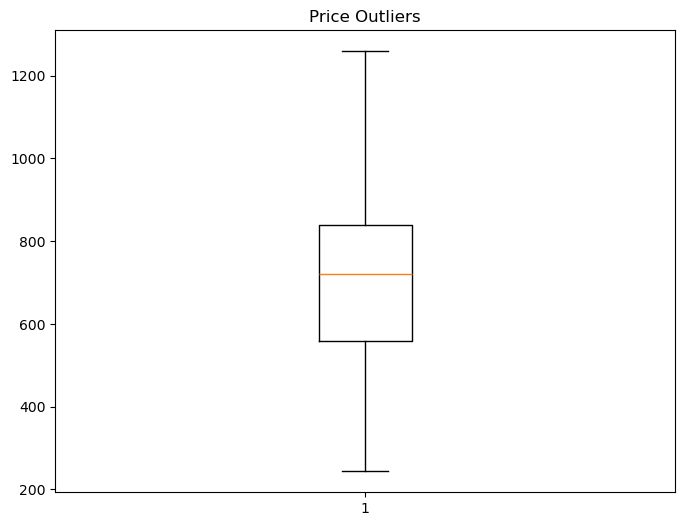

In [167]:
plt.figure(figsize=(8,6))
plt.boxplot(df["Prices"])

plt.title("Price Outliers")
plt.show()

### Insights

* Most formal shirts on Myntra are priced in the mid-range segment.
* The absence of extreme outliers suggests a consistent pricing strategy across brands.
* Customers can find a wide variety of shirts within an affordable price range.
* The dataset shows moderate price variation, catering to different customer budgets.

### Interpretation

* The median shirt price is approximately ₹720.
* The middle 50% of shirt prices lie between ₹560 and ₹840.
* Prices range from approximately ₹300 to ₹1260.
* No significant outliers are observed, indicating a balanced price distribution.

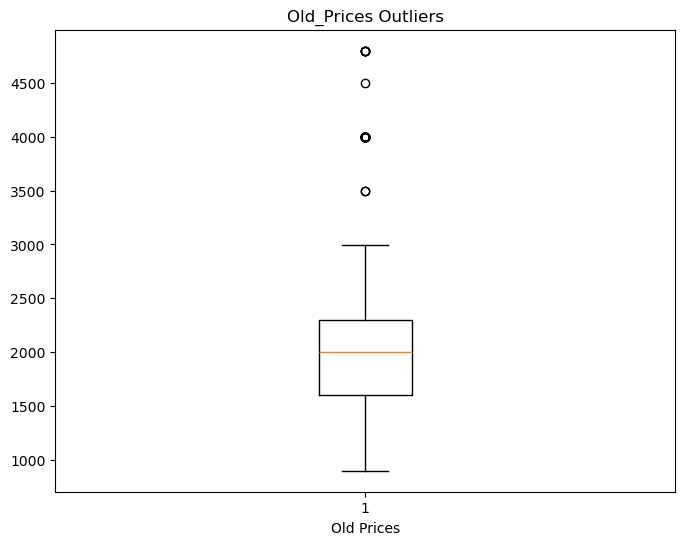

In [163]:
plt.figure(figsize=(8,6))
plt.boxplot(df["Old_Prices"])
plt.xlabel("Old Prices")

plt.title("Old_Prices Outliers")
plt.show()

In [ ]:
Insights

✅ Most formal shirts have original prices between ₹1600 and ₹2300.

✅ A few premium shirts have significantly higher original prices (₹3500–₹4800).

✅ The presence of high-value outliers indicates that Myntra offers both mid-range and premium formal shirts.

✅ The majority of products are concentrated around the ₹2000 price segment.

In [ ]:
## Interpretation
* The median old price is approximately ₹2000.
* The middle 50% of old prices lie between ₹1600 and ₹2300.
* Most products have original prices below ₹3000.
* Several outliers are present above ₹3500, reaching up to approximately ₹4800.

In [40]:
Q3 = df['Price'].quantile(0.75)
Q1 = df['Price'].quantile(0.25)

IQR = Q3 - Q1

print(IQR)

251.0


In [37]:
Q3 = df['Old_Prices'].quantile(0.75)
Q1 = df['Old_Prices'].quantile(0.25)

IQR = Q3 - Q1

print(IQR)

700.0


In [38]:
Q3 = df['Discounts'].quantile(0.75)
Q1 = df['Discounts'].quantile(0.25)

IQR = Q3 - Q1

print(IQR)

17.0


In [39]:
df

,Brands,Products,Prices,Old_Prices,Discounts,Ratings,Reviews
0,HIGHLANDER,Slim Fit Opaque Casual Shirt,479,1599,70,4.2,208.8
1,HIGHLANDER,Slim Fit Opaque Casual Shirt,463,1599,71,4.2,208.8
2,Park Avenue,Slim Fit Formal Shirt,492,1699,71,4.4,728.0
3,Raymond,Slim Fit Cotton Formal Shirt,587,2099,72,4.3,335.0
4,Blackberrys,Opaque Formal Shirt,1027,2055,50,4.1,307.0
...,...,...,...,...,...,...,...
414,Park Avenue,Slim Fit Cotton Formal Shirt,990,2199,55,4.3,842.0
415,Arrow,Regular Fit Formal Shirt,779,1999,61,4.4,226.0
416,Turtle,Slim Fit Casual Shirt,1189,1699,30,4.4,24.0
417,CAHOOT,Casual Shirt,725,2199,67,4.4,258.0


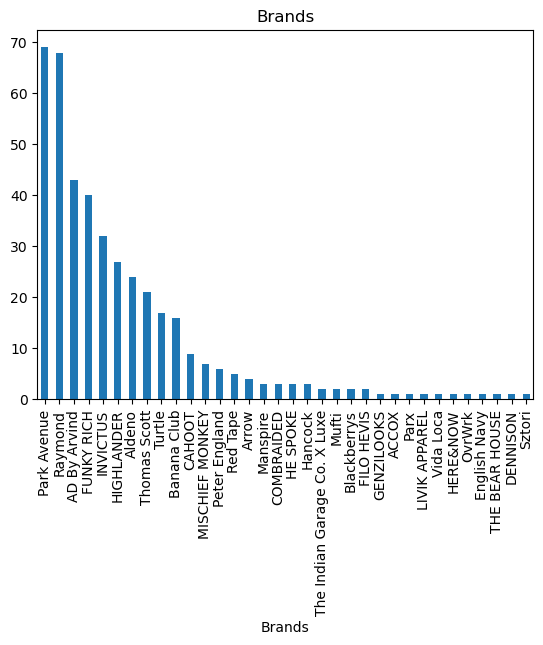

In [169]:
df['Brands'].value_counts().plot(kind = 'bar')
plt.title("Brands")
plt.show()

## Insights

* Park Avenue and Raymond dominate the category, offering the largest number of formal shirts.
* The product distribution is uneven, with a few brands contributing a major share of the listings.
* Several brands have limited product availability, indicating niche or specialized offerings.
* Customers have more choices from leading brands such as Park Avenue, Raymond, and Allen Solly.

## Interpretation

* The bar chart shows the number of formal shirts available for each brand.
* Park Avenue has the highest number of products (around 69).
* Raymond is the second most represented brand (around 68).
* Brands like Allen Solly, HIGHLANDER, INVICTUS, Van Heusen also have a strong presence.
* Many brands have only a few products listed.

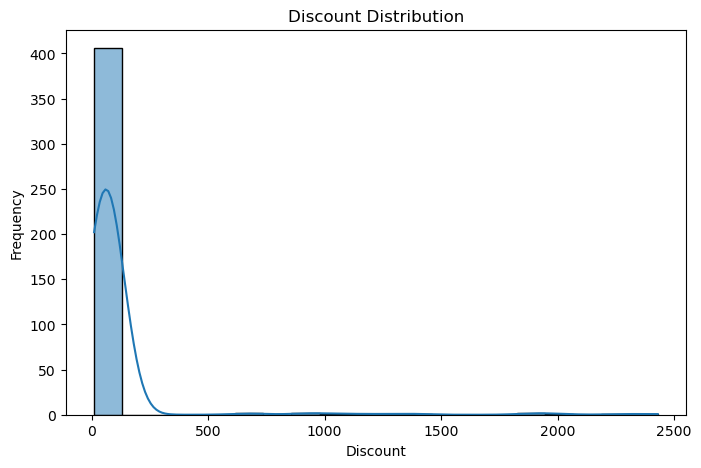

In [178]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot( df['Discounts'],kde=True, bins=20)

plt.title("Discount Distribution")
plt.xlabel("Discount")
plt.ylabel("Frequency")
plt.show()

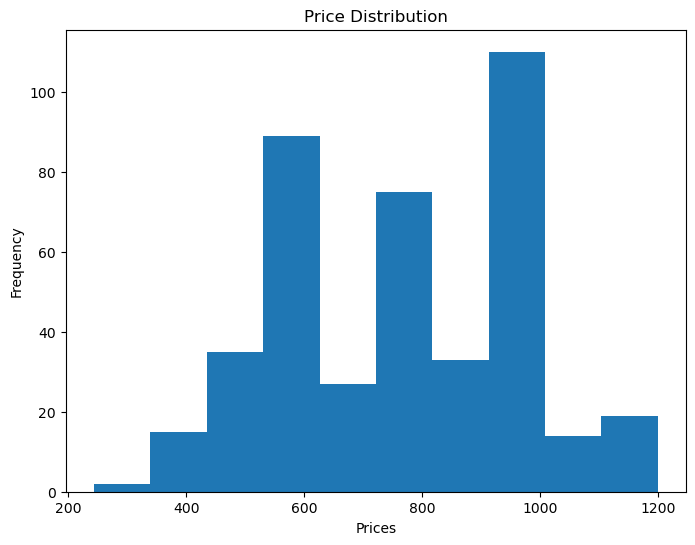

In [164]:
plt.figure(figsize=(8,6))
plt.hist(df['Prices'], bins=10)

plt.title("Price Distribution")
plt.xlabel("Prices")
plt.ylabel("Frequency")

plt.show()

## Insights

* Most formal shirts are available at affordable to mid-range prices.
* High-priced shirts are less common in the dataset.
* The price distribution is not symmetric and contains a long right tail.
* Customers have more options in the budget and mid-range categories than in the premium category.

## Interpretation

* Most shirt prices are concentrated in the lower price range.
* As the price increases, the number of products decreases.
* The distribution is positively skewed (right-skewed).
* Only a few products belong to the higher-price segment.

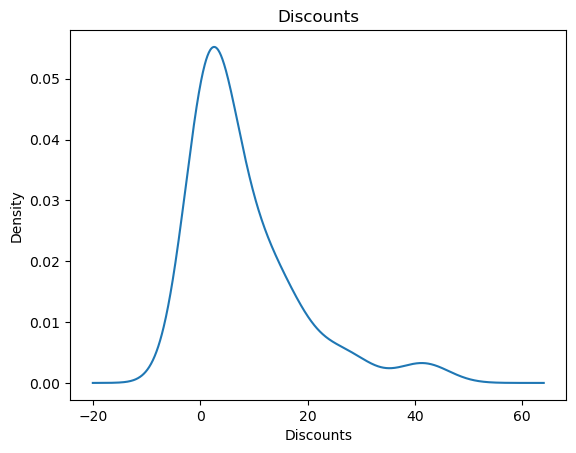

In [170]:
df['Discounts'].value_counts().plot(kind = 'kde')
plt.xlabel("Discounts")
plt.title("Discounts")
plt.show()

## Insights

* Most formal shirts offer discounts between 50% and 60%.
* Deep discounts above 70% are relatively rare.
* The discount strategy is concentrated around a moderate-to-high discount range.
* Customers are most likely to find products with discounts near 55%.

## Interpretation

* The KDE plot shows the distribution of discount percentages across formal shirts.
* The highest density is around 50%–60% discount, indicating that most products fall in this range.
* The distribution is right-skewed, with fewer products having very high discounts.
* A small secondary bump suggests a limited number of products with exceptionally high discounts.

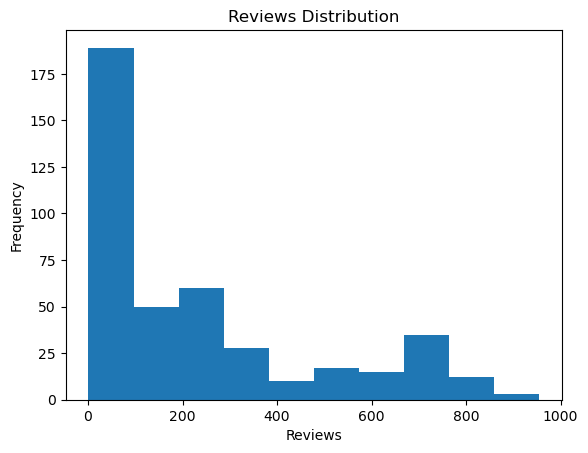

In [165]:
plt.hist(df['Reviews'], bins=10)
plt.title("Reviews Distribution")
plt.xlabel("Reviews")
plt.ylabel("Frequency")
plt.show()

## Insights

* Some review counts are repeated across multiple products.
* A few review values dominate the dataset, while many others occur less frequently.
* Customer engagement varies significantly among products.
* Certain products receive substantially more reviews than others.

## Interpretation

* The review value 1.4 appears most frequently in the dataset.
* Review values around 208.8, 9.0, and 7.0 also occur multiple times.
* Most review counts occur only a limited number of times.
* The distribution of review values is uneven across products.

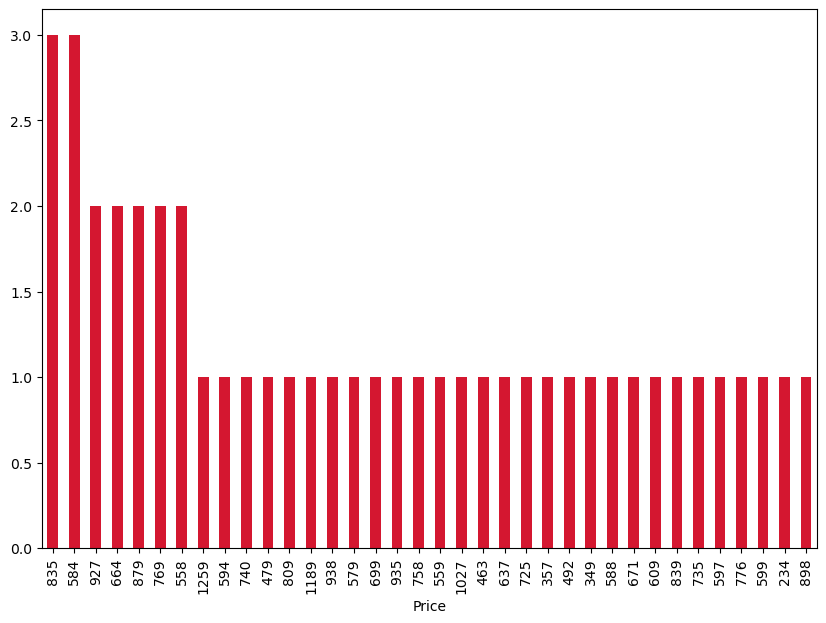

In [42]:
plt.figure(figsize=(10,7))
df['Price'].value_counts().plot(kind = 'bar',color = '#d41730')
plt.show()

## Insights

* Most price values are unique.
* Only a few price points are repeated across multiple products
* The dataset contains a diverse range of product prices.
* There is no single dominant price point in the formal shirt category.

## Interpretation

* Prices ₹835 and ₹584 appear most frequently (3 times each).
* Prices such as ₹927, ₹664, ₹879, ₹769, ₹558 appear twice.
* Most other prices occur only once.
* There is a wide variety of price points in the dataset.

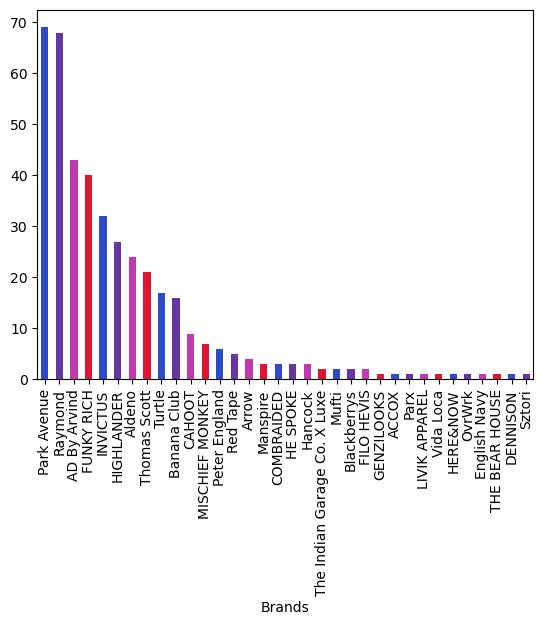

In [168]:
df['Brands'].value_counts().plot(kind = 'bar',color=['#2c4bc7','#6637a1','#c238ad','#de1631'])
plt.show()

## Insights

* Park Avenue and Raymond dominate the formal shirt category.
* The top 5 brands contribute a large share of the total products.
* Product availability is concentrated among a few established brands.
* Several brands have only 1–3 products, suggesting niche offerings or limited inventory.
* Customers have the widest variety of choices from Park Avenue and Raymond.

## Interpretation

* Park Avenue has the highest number of formal shirts (~69 products).
* Raymond is the second-largest contributor (~68 products).
* AD By Arvind and FUNKY RICH also have a significant presence.
* Brands such as HIGHLANDER, INVICTUS, Allen Solly, Thomas Scott, and Banana Club have a moderate number of listings.
* Many brands have fewer than 10 products, indicating lower market presence in this dataset.

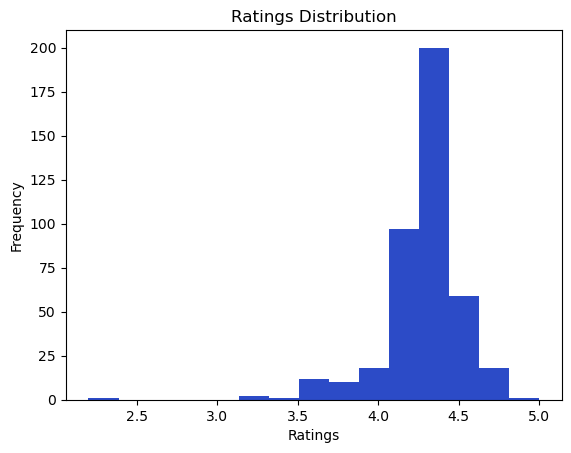

In [181]:
df['Ratings'].plot(kind='hist',bins=15,color='#2c4bc7')

plt.title('Ratings Distribution')
plt.xlabel('Ratings')
plt.ylabel('Frequency')

plt.show()

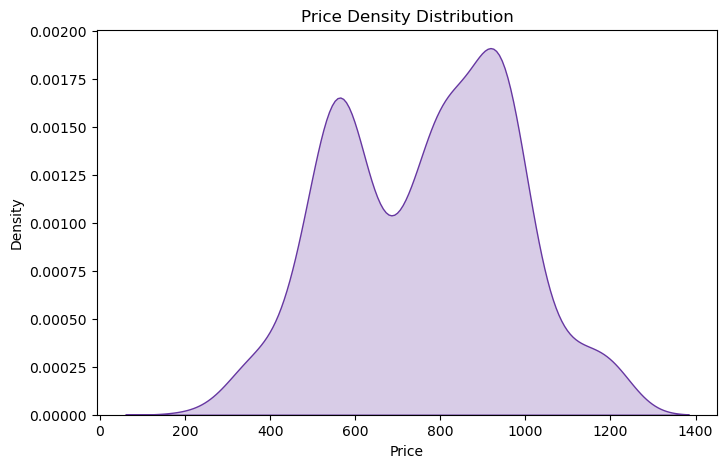

In [186]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.kdeplot(df['Prices'],
            fill=True,
            color='#6637a1')

plt.title('Price Density Distribution')
plt.xlabel('Price')

plt.show()

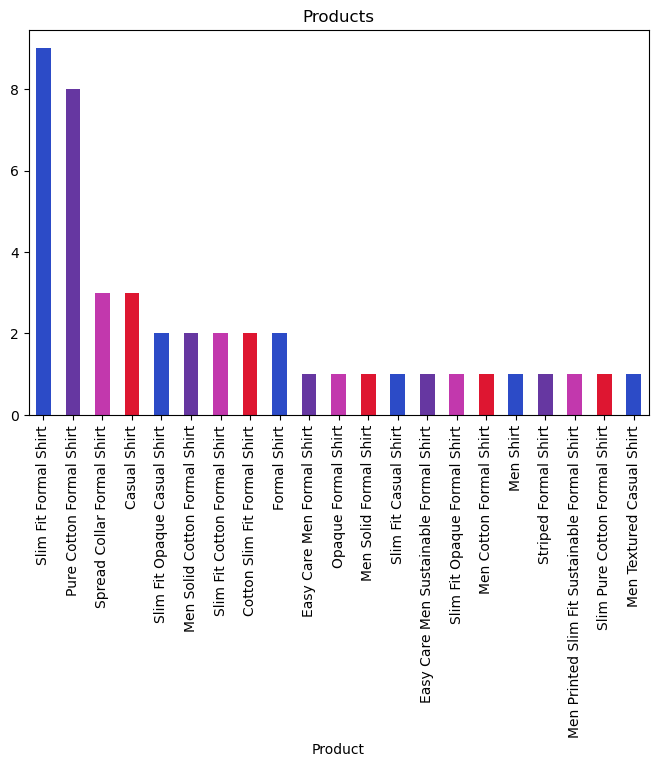

In [44]:
plt.figure(figsize=(8,5))
df['Product'].value_counts().plot(kind = 'bar',color=['#2c4bc7','#6637a1','#c238ad','#de1631'])
plt.title("Products")
plt.show()

## Insights

* Slim Fit Formal Shirts are the most popular product category in the dataset.
* Pure Cotton Formal Shirts also have strong representation, indicating customer preference for comfort and fabric quality.
* The dataset is dominated by formal shirt variants rather than casual shirts.
* Product offerings are diversified, but a few shirt styles account for most listings.

## Interpretation

* "Slim Fit Formal Shirt" is the most common product type (around 9 products).
* "Pure Cotton Formal Shirt" is the second most frequent product type (around 8 products).
* Products such as "Spread Collar Formal Shirt" and "Casual Shirt" appear moderately often.
* Most other product names occur only once or twice.

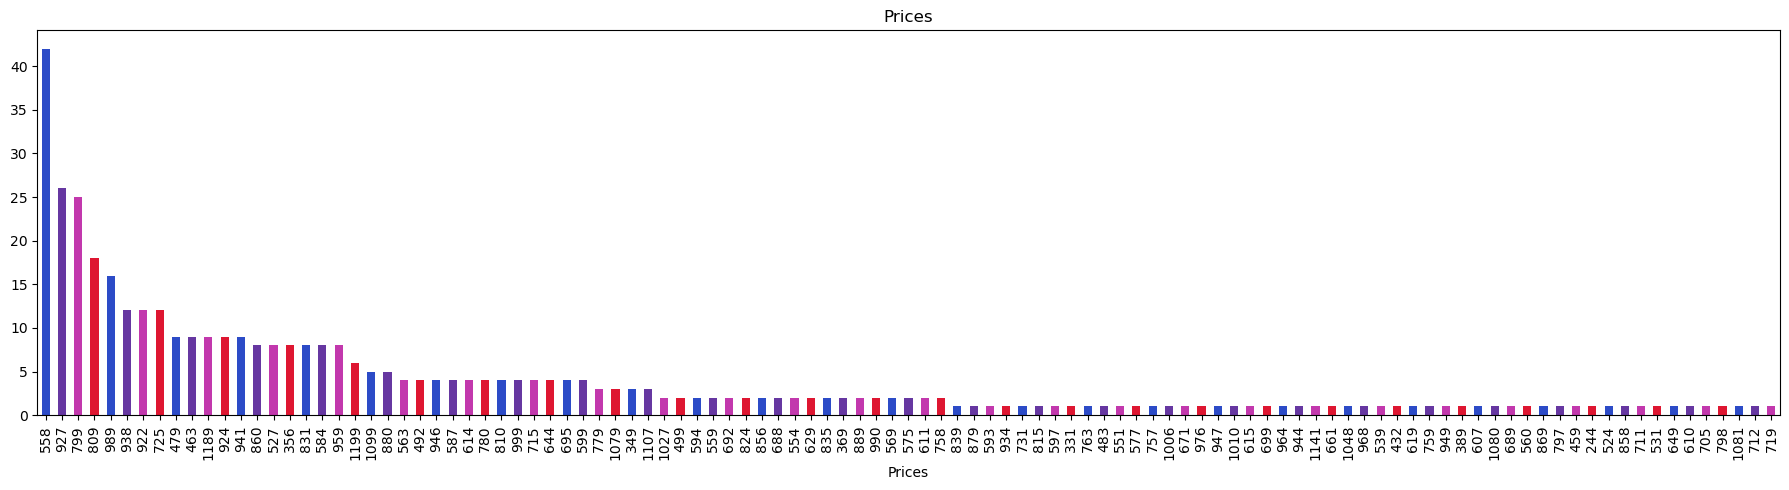

In [60]:
plt.figure(figsize=(18,5))
df['Prices'].value_counts().plot(kind = 'bar',color=['#2c4bc7','#6637a1','#c238ad','#de1631'])
plt.title("Prices")
plt.tight_layout()
plt.show()

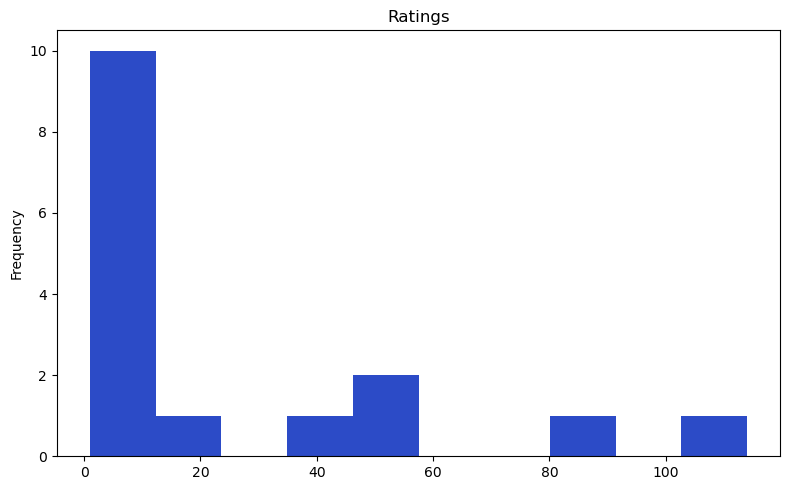

In [67]:
plt.figure(figsize=(8,5))
df['Ratings'].value_counts().plot(kind = 'hist',color=['#2c4bc7','#6637a1','#c238ad'])
plt.title("Ratings")
plt.tight_layout()
plt.show()

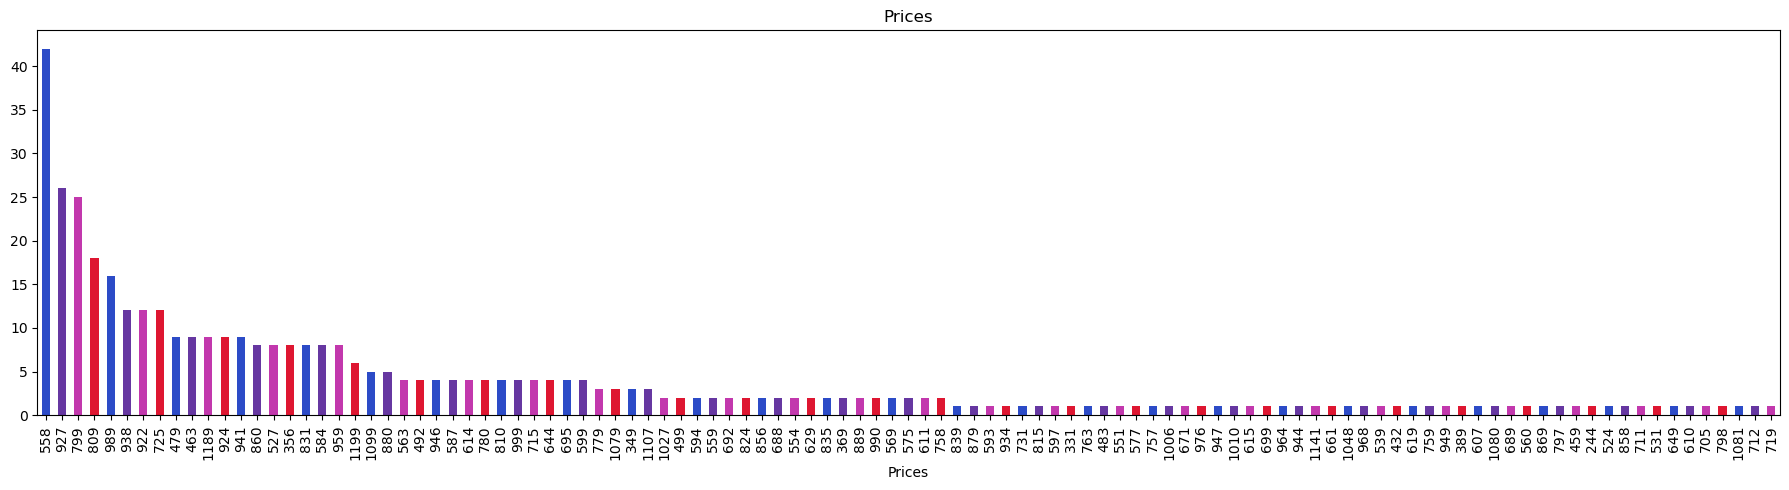

In [68]:
plt.figure(figsize=(18,5))
df['Prices'].value_counts().plot(kind = 'bar',color=['#2c4bc7','#6637a1','#c238ad','#de1631'])
plt.title("Prices")
plt.tight_layout()
plt.show()

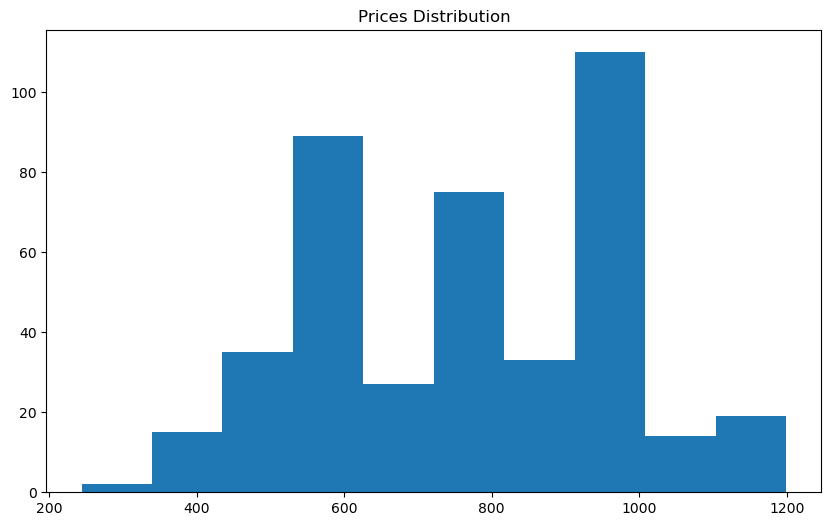

In [70]:
plt.figure(figsize=(10,6))
plt.hist(df["Prices"])
plt.title("Prices Distribution")
plt.show()

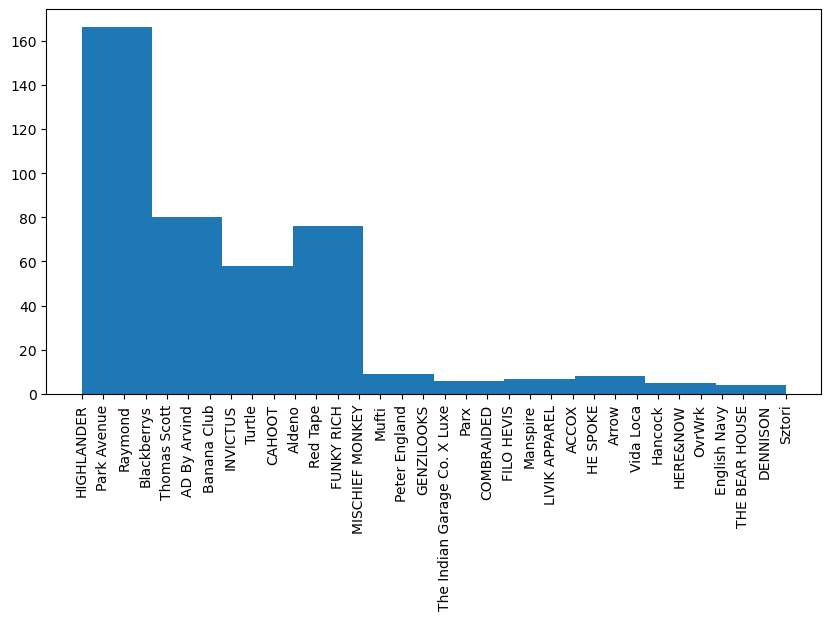

In [71]:
plt.figure(figsize=(10,5))
plt.hist(df['Brands'])
plt.xticks(rotation=90)
plt.show()

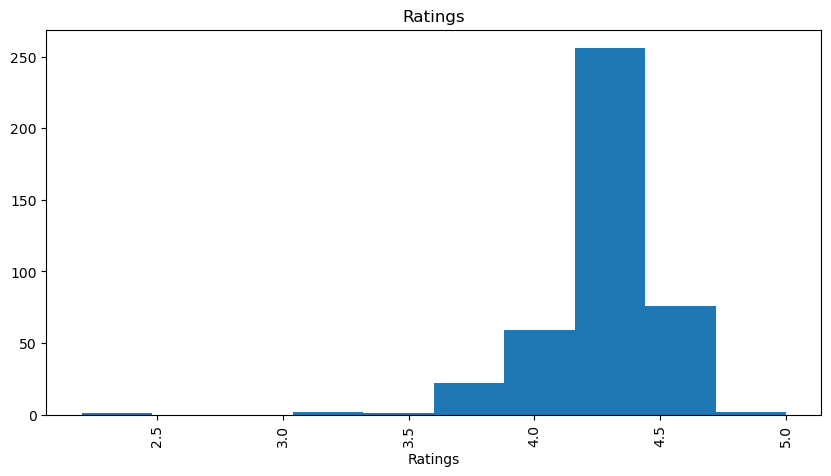

In [73]:
plt.figure(figsize=(10,5))
plt.hist(df['Ratings'])
plt.xticks(rotation=90)
plt.xlabel("Ratings")
plt.title("Ratings")
plt.show()

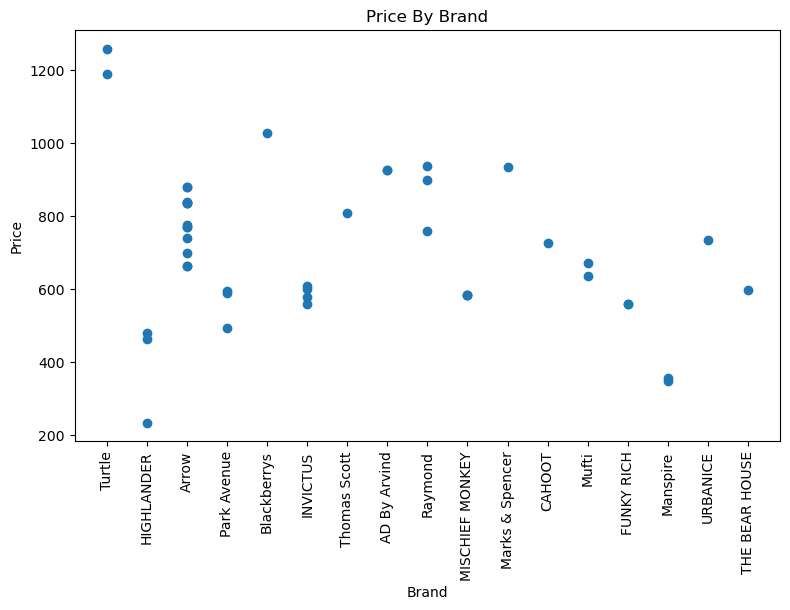

In [47]:
plt.figure(figsize=(8,6))
plt.scatter(df['Brand'],df['Price'])

plt.xlabel("Brand")
plt.ylabel("Price")

plt.xticks(rotation=90)

plt.tight_layout()
plt.title("Price By Brand")
plt.show()

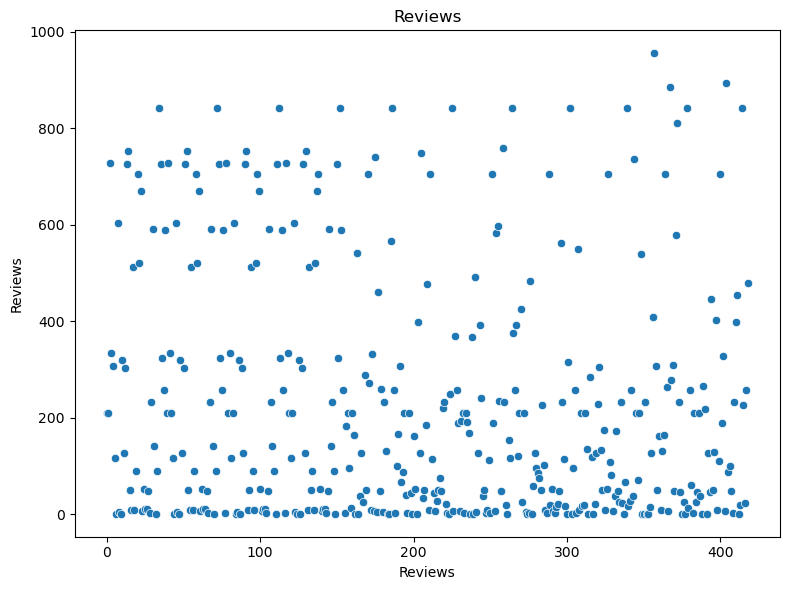

In [81]:
plt.figure(figsize=(8,6))
sns.scatterplot(df['Reviews'])

plt.xlabel("Reviews")

plt.title("Reviews")

plt.tight_layout()

plt.show()

<Figure size 1200x600 with 0 Axes>

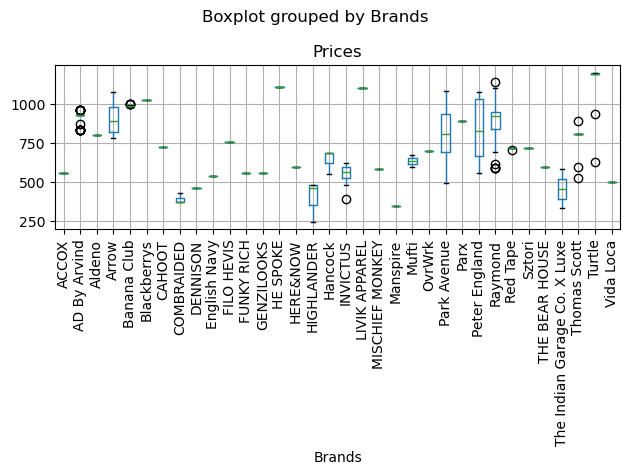

In [83]:
plt.figure(figsize=(12,6))
df.boxplot(column='Prices', by='Brands')

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

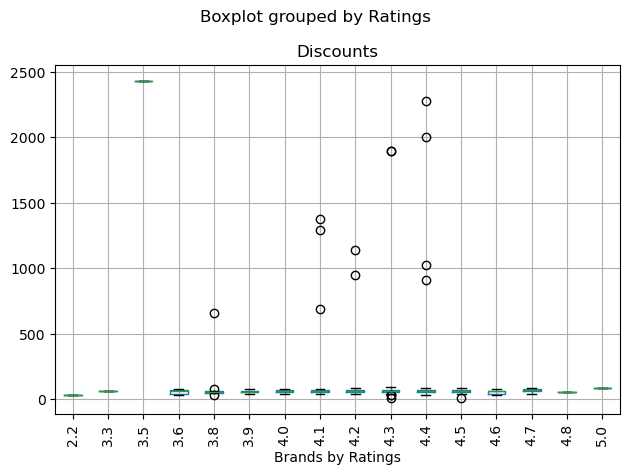

In [85]:
plt.figure(figsize=(12,6))
df.boxplot(column='Discounts', by='Ratings')

plt.xlabel("Brands by Ratings")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

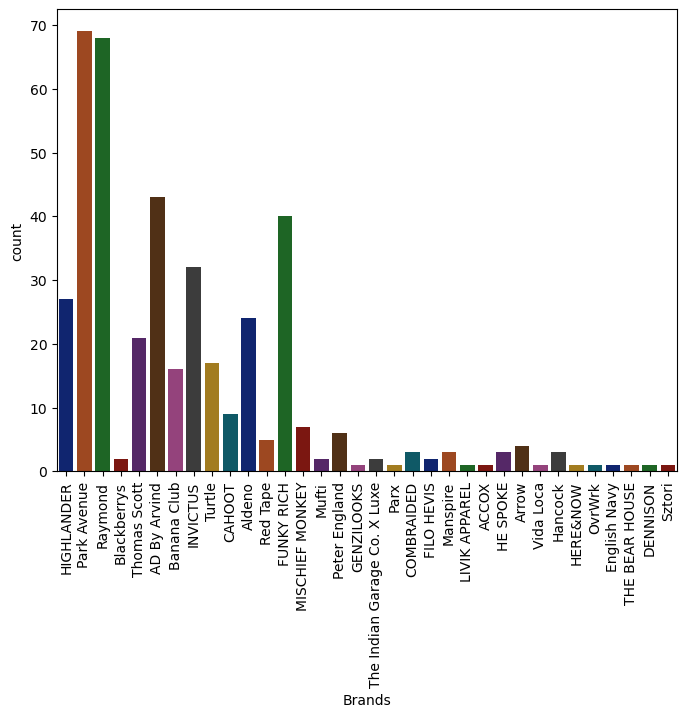

In [86]:
plt.figure(figsize=(8,6))
sns.countplot(x="Brands", data=df , palette= 'dark')
plt.xticks(rotation=90)
plt.show()

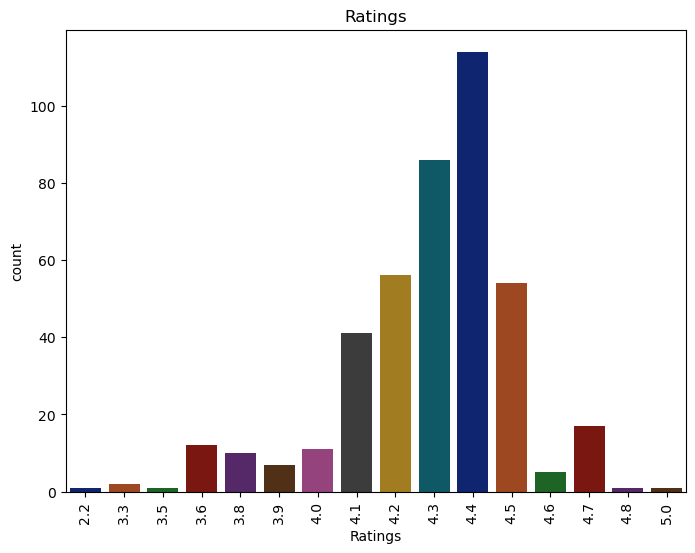

In [104]:
plt.figure(figsize=(8,6))
sns.countplot(x="Ratings", data=df , palette= 'dark')
plt.xlabel("Ratings")
plt.title("Ratings")
plt.xticks(rotation=90)
plt.show()

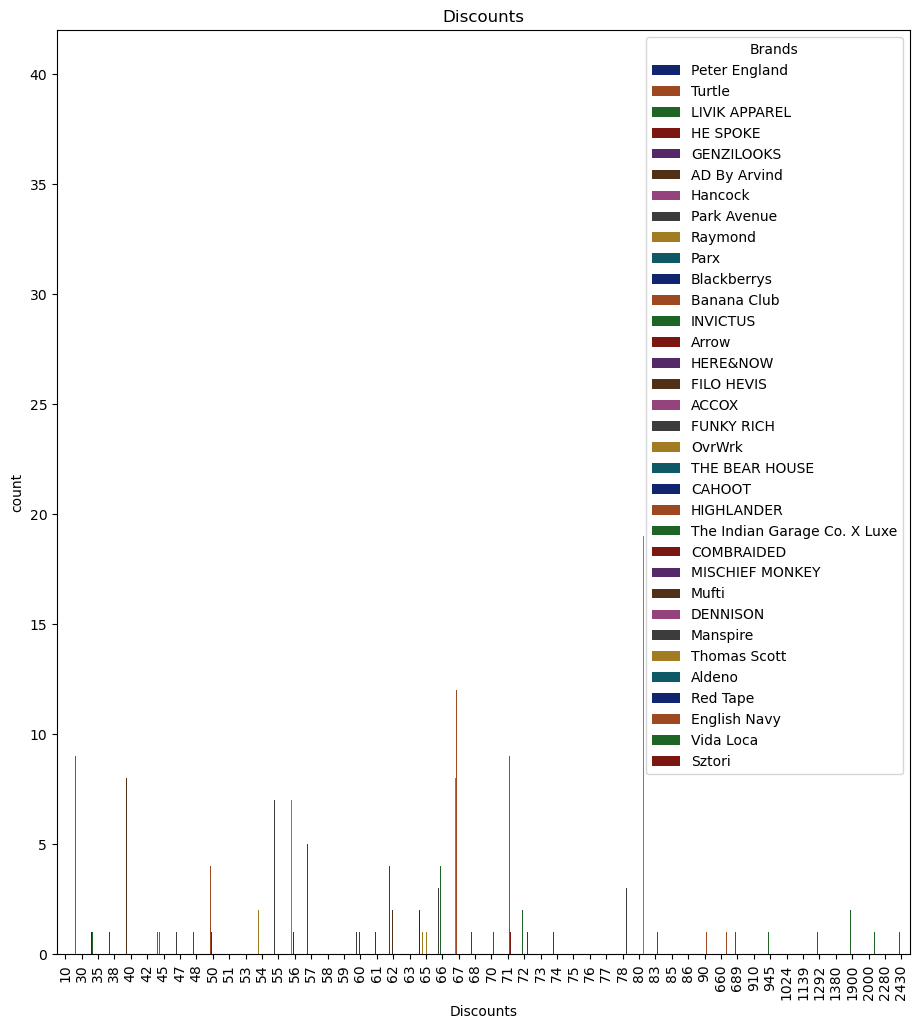

In [111]:
plt.figure(figsize=(11,12))
sns.countplot(x="Discounts", data=df , palette= 'dark' , hue = df["Brands"])
plt.xlabel("Discounts")
plt.title("Discounts")
plt.xticks(rotation=90)
plt.show()

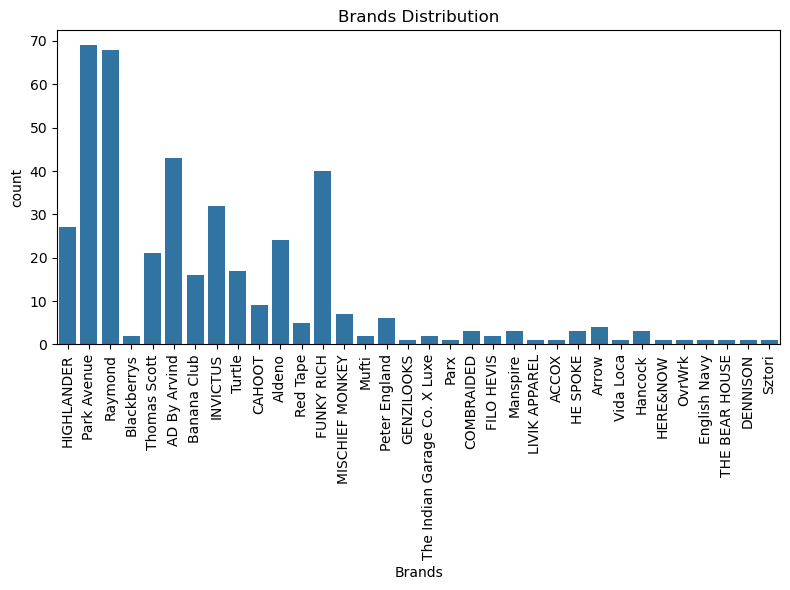

In [112]:
plt.figure(figsize=(8,6))
sns.countplot(x="Brands", data=df)

plt.xticks(rotation=90)
plt.xlabel("Brands")
plt.title("Brands Distribution")
plt.tight_layout()
plt.show()

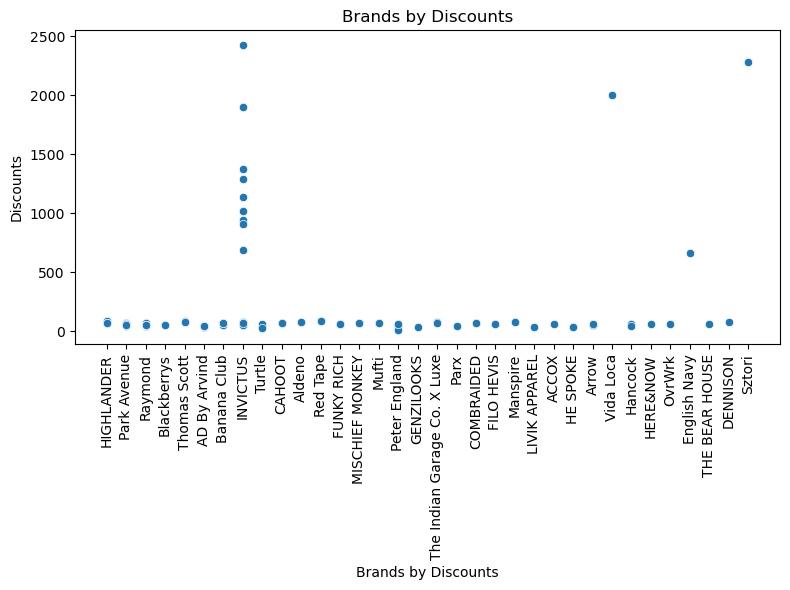

In [118]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="Brands", y="Discounts", data=df)

plt.xticks(rotation=90)
plt.xlabel("Brands by Discounts")
plt.title("Brands by Discounts")
plt.tight_layout()
plt.show()

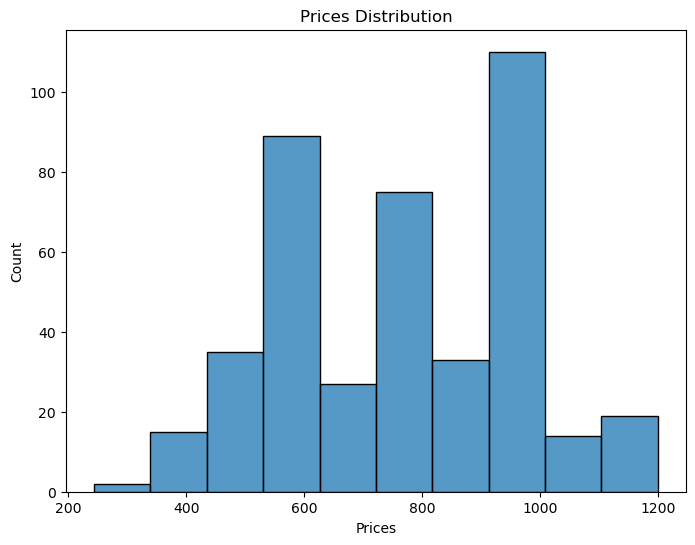

In [119]:
plt.figure(figsize=(8,6))
sns.histplot(df["Prices"])
plt.title("Prices Distribution")
plt.show()

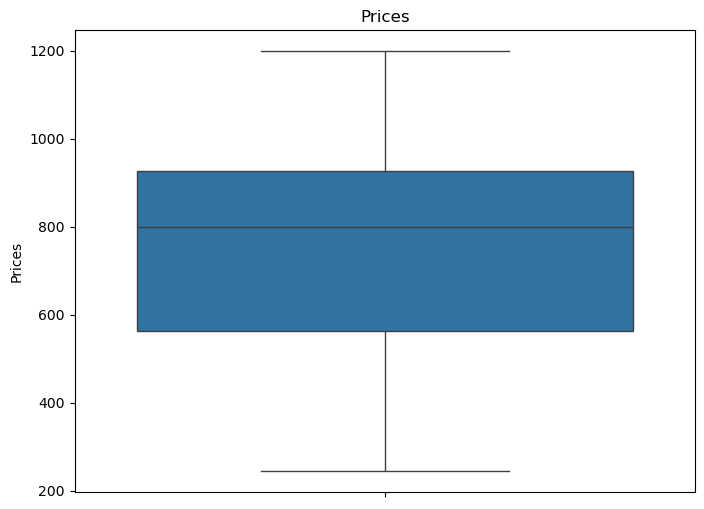

In [120]:
plt.figure(figsize=(8,6))

sns.boxplot(df["Prices"])
plt.title("Prices")

plt.show()

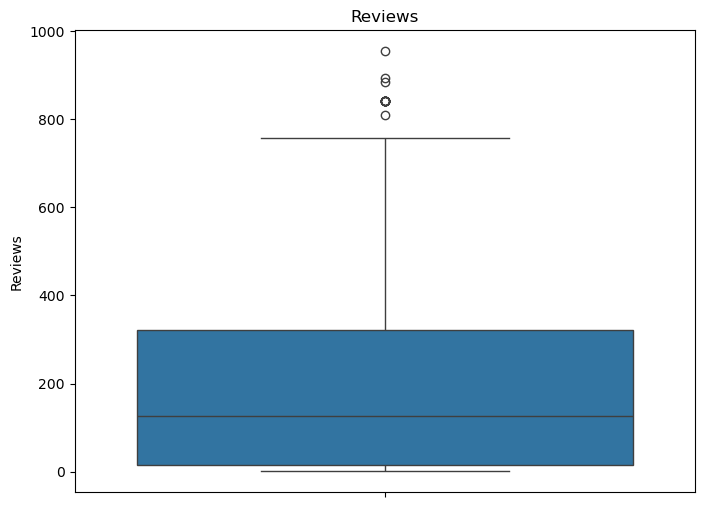

In [121]:
plt.figure(figsize=(8,6))

sns.boxplot(df["Reviews"])
plt.title("Reviews")

plt.show()

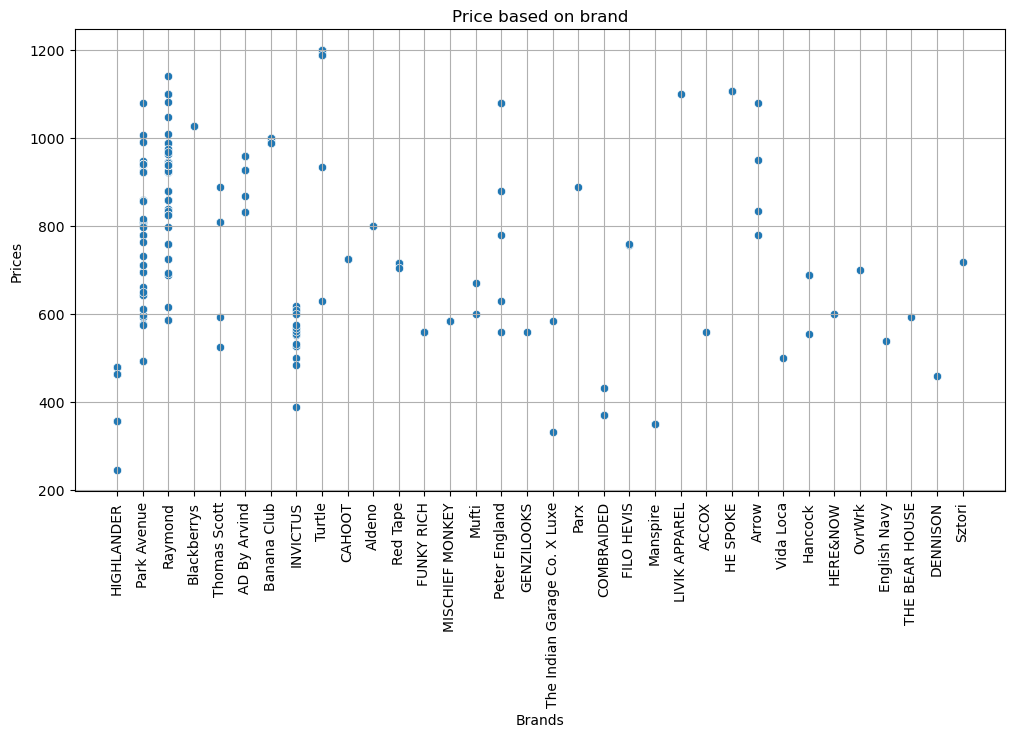

In [122]:
plt.figure(figsize=(12,6))
sns.scatterplot(x="Brands", y="Prices", data=df)

plt.xticks(rotation=90)

plt.title("Price based on brand")

plt.grid(True)
plt.show()     # Visualizing relationship between brand and product price

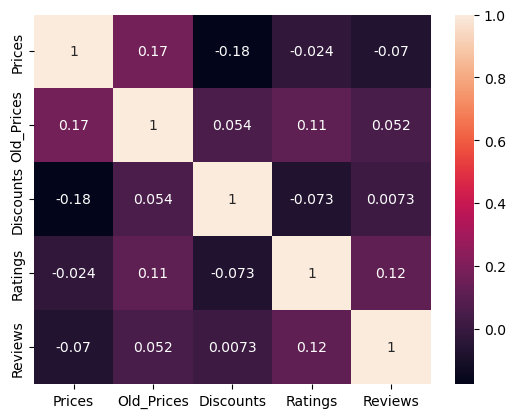

In [123]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True)

plt.show()

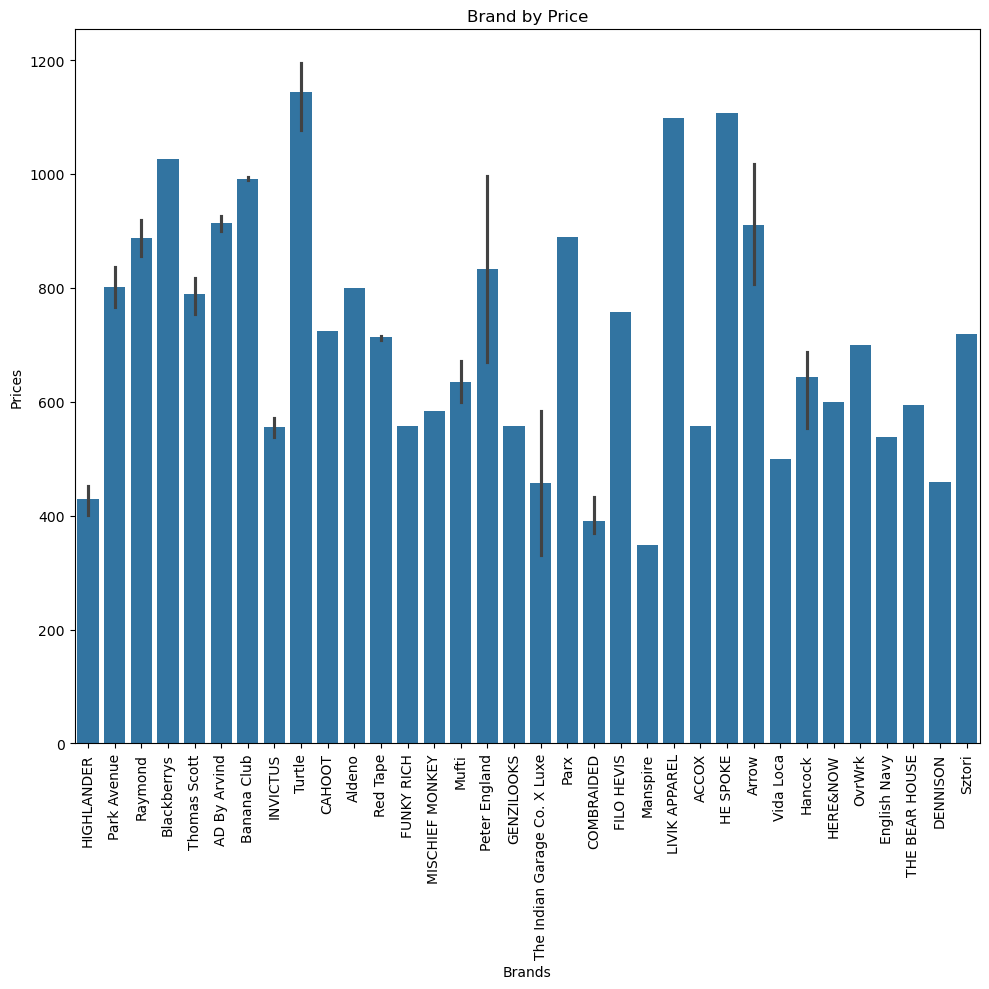

In [124]:
plt.figure(figsize=(10,10))
sns.barplot(data=df , x='Brands',y='Prices')
plt.xticks(rotation = 90)
plt.title("Brand by Price")
plt.tight_layout()
plt.show()

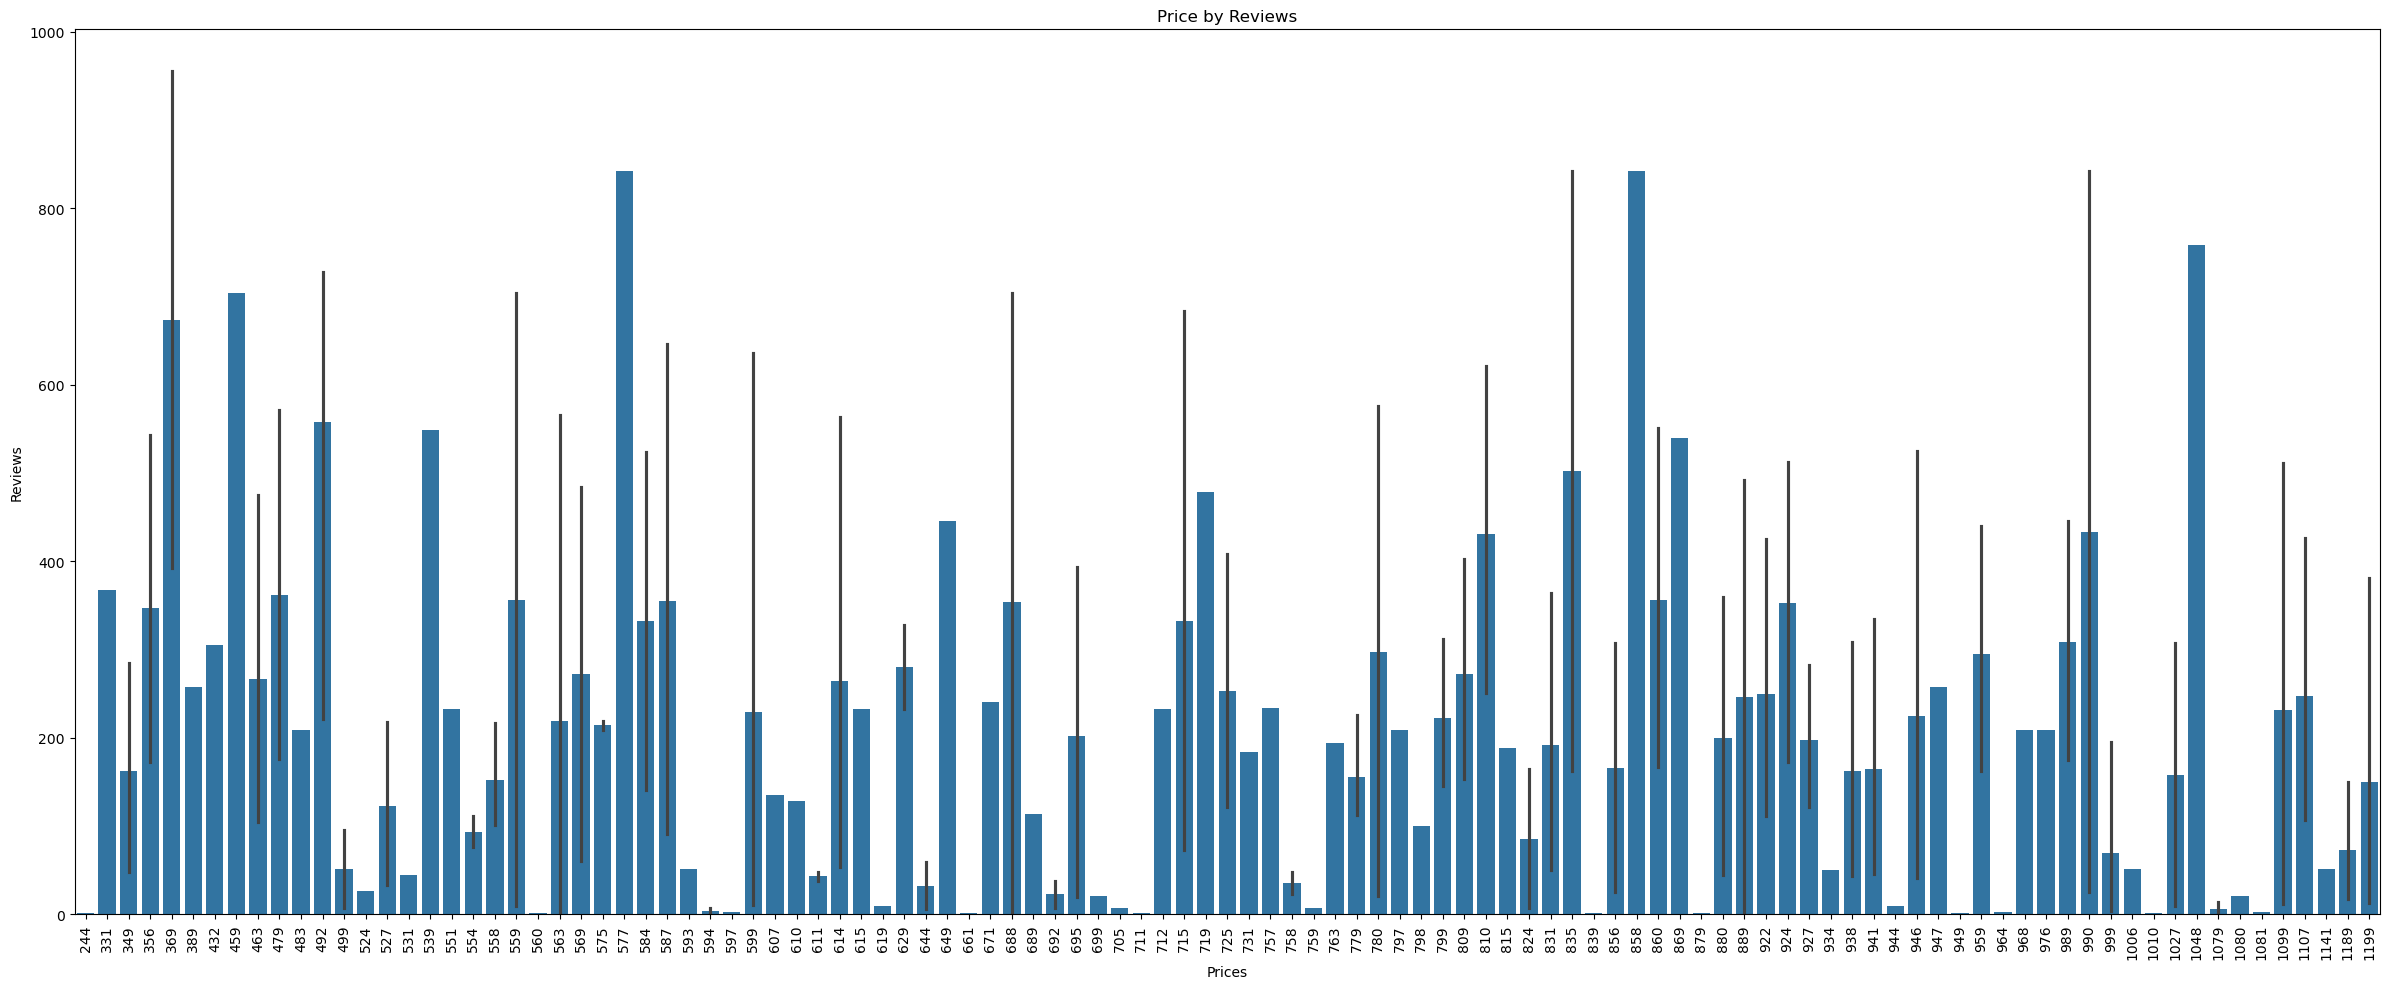

In [130]:
plt.figure(figsize=(24,10))
sns.barplot(data=df , x='Prices',y='Reviews')
plt.xticks(rotation = 90)
plt.title("Price by Reviews")
plt.tight_layout()
plt.show()

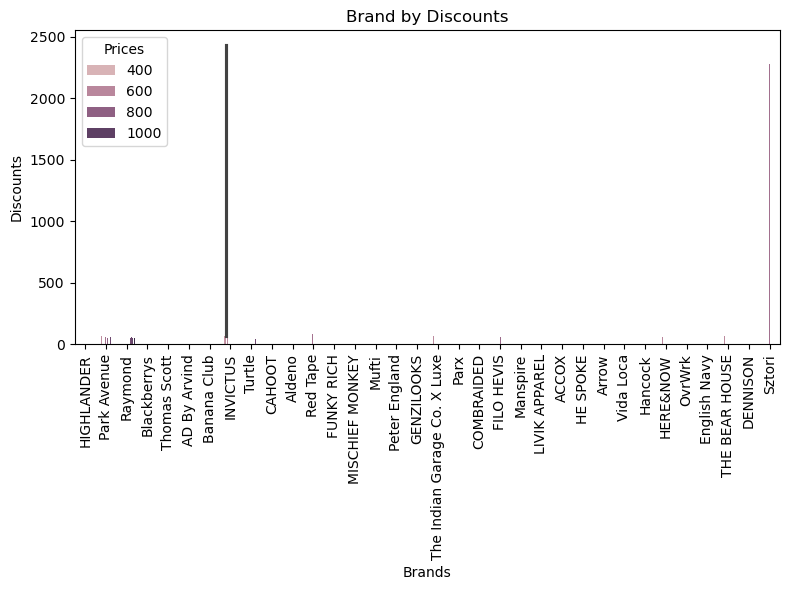

In [132]:
plt.figure(figsize=(8,6))
sns.barplot(data=df , x='Brands',y='Discounts', hue='Prices')
plt.xticks(rotation = 90)

plt.title("Brand by Discounts")
plt.tight_layout()
plt.show()

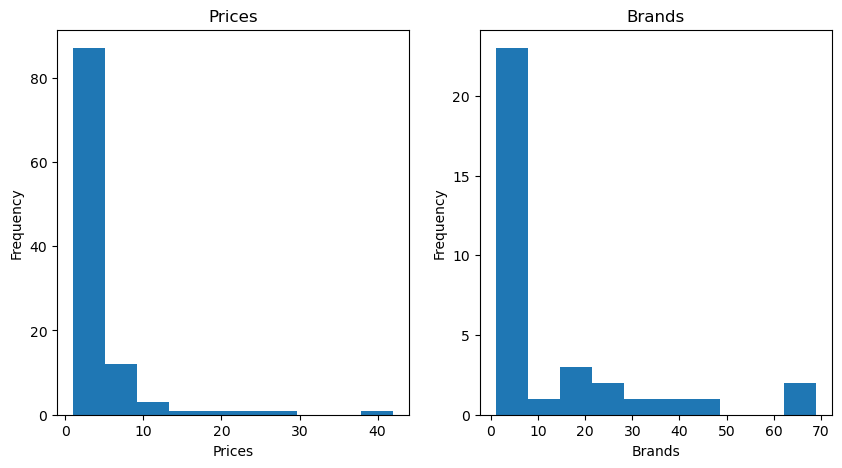

In [143]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,2)
df['Brands'].value_counts().plot(kind = 'hist')
plt.title("Brands")
plt.xlabel("Brands")

plt.subplot(1,2,1)
df['Prices'].value_counts().plot(kind = 'hist')
plt.title("Prices")
plt.xlabel("Prices")

plt.show()

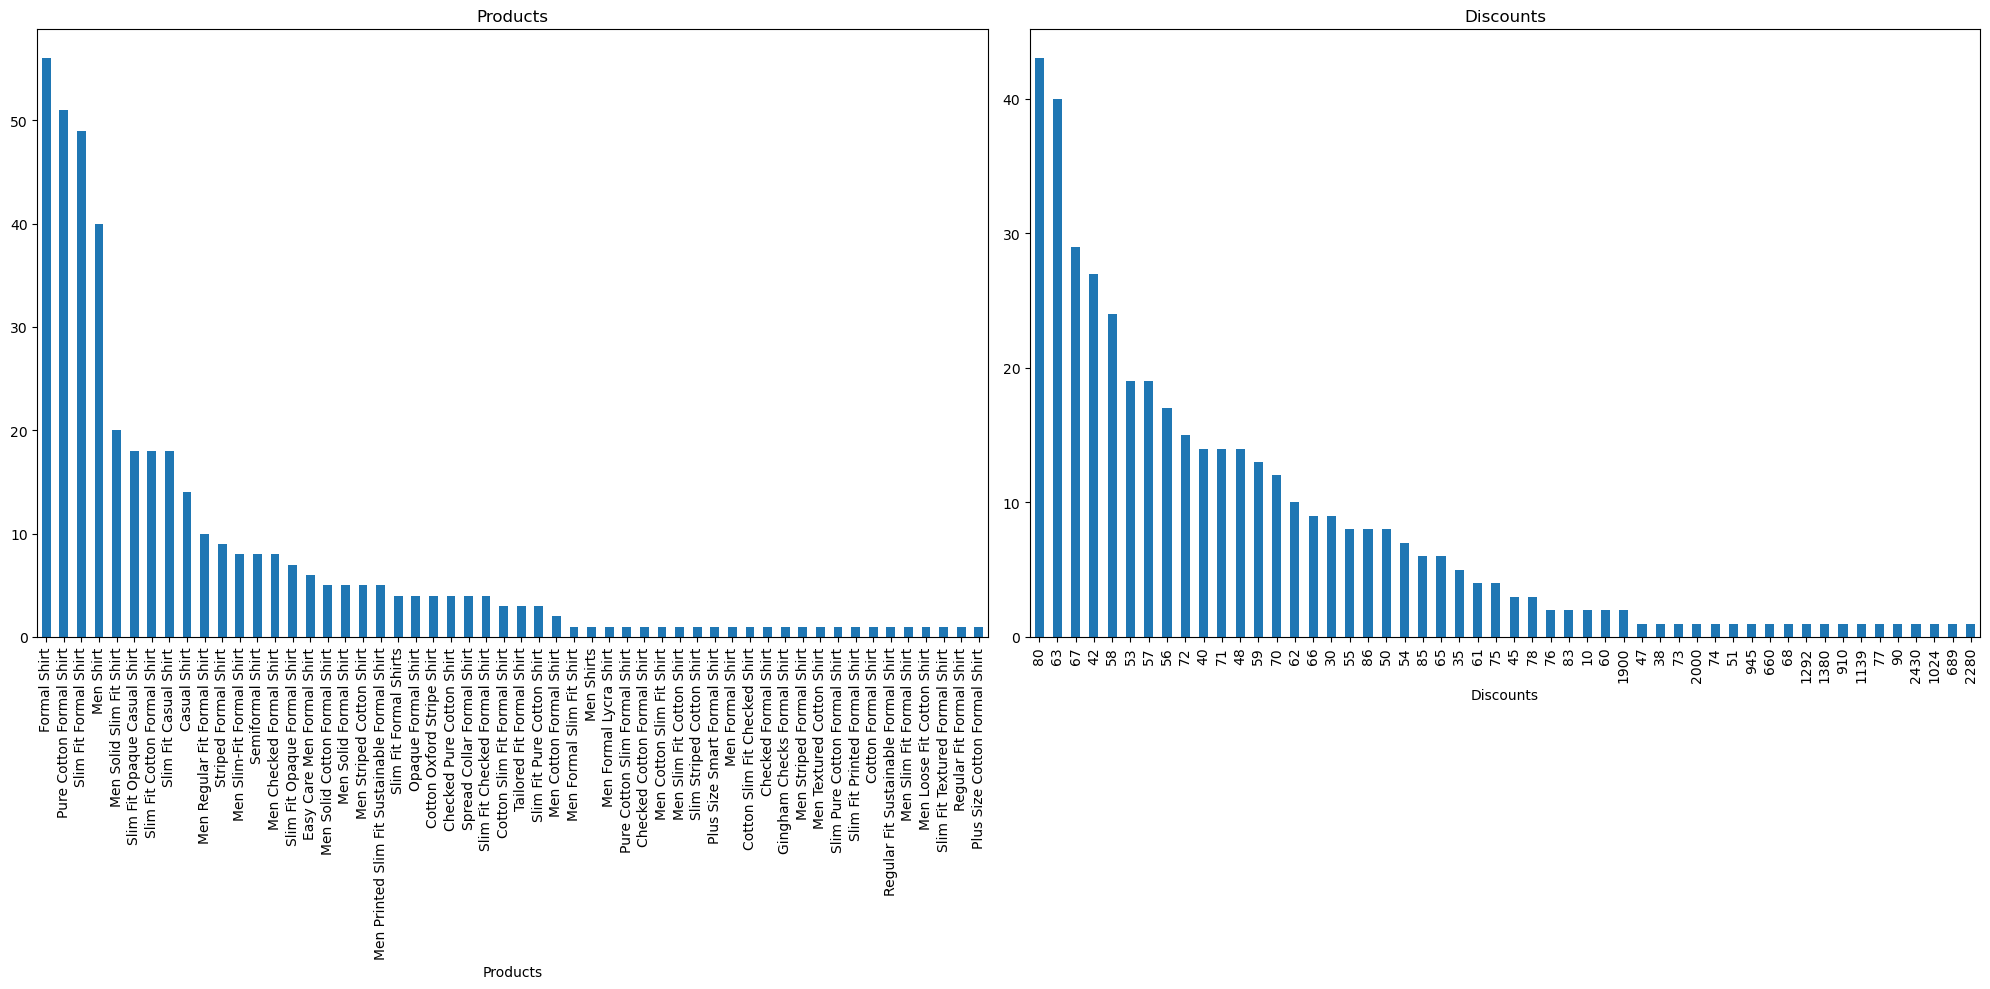

In [142]:
plt.figure(figsize=(20,10))

plt.subplot(1,2,1)
df['Products'].value_counts().plot(kind = 'bar')
plt.title("Products")
plt.xlabel("Products")
plt.tight_layout()

plt.subplot(1,2,2)
df['Discounts'].value_counts().plot(kind = 'bar')
plt.title("Discounts")
plt.xlabel("Discounts")
plt.tight_layout()

plt.show()

### 

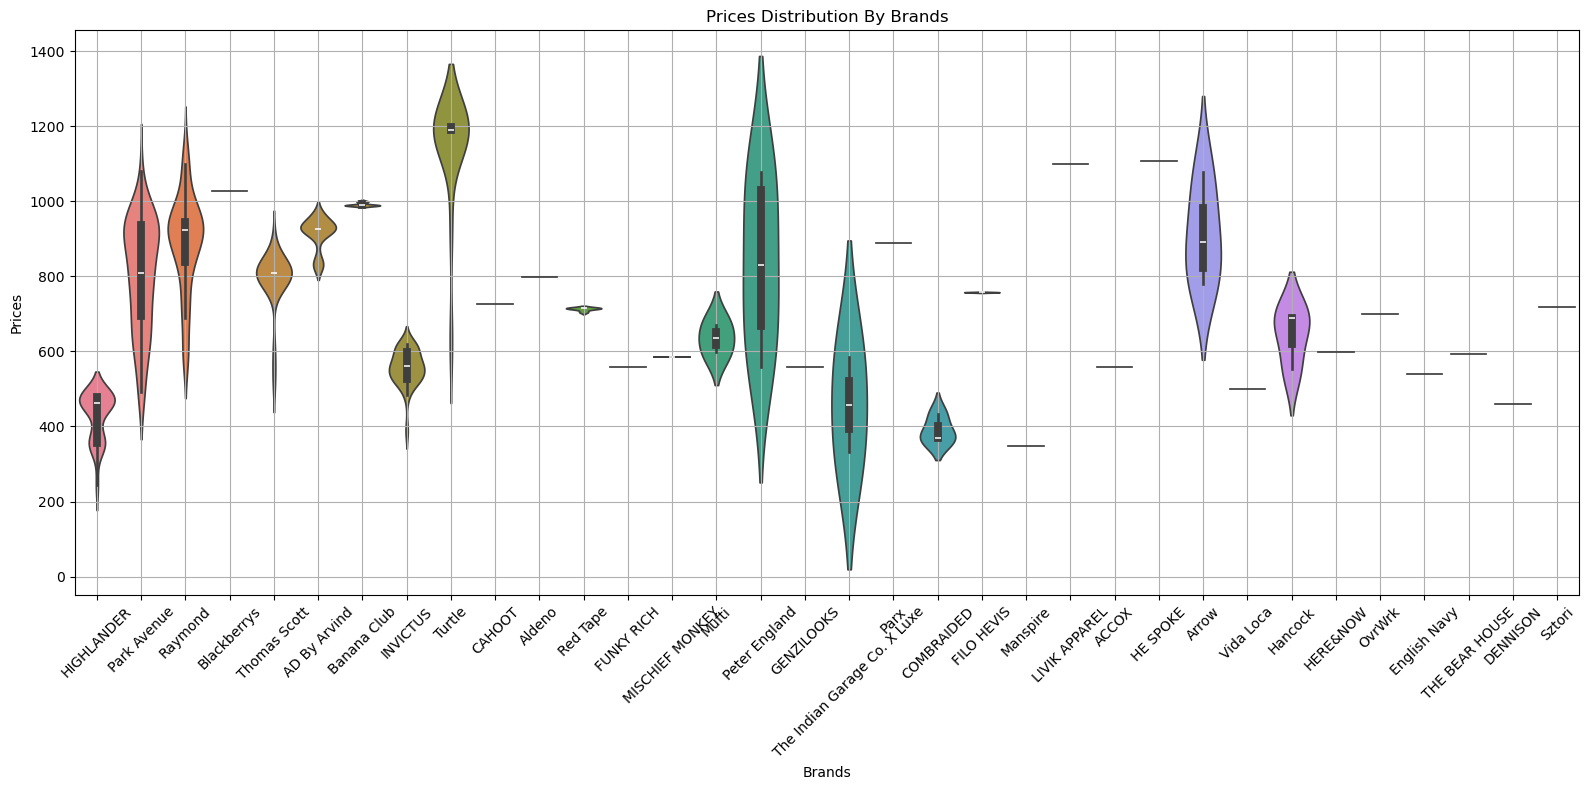

In [145]:
plt.figure(figsize=(16,8))

sns.violinplot(data= df,
              x = 'Brands',
              y = 'Prices',
              hue= 'Brands')
plt.xticks(rotation = 45)
plt.title("Prices Distribution By Brands")

plt.tight_layout()
plt.grid(True)

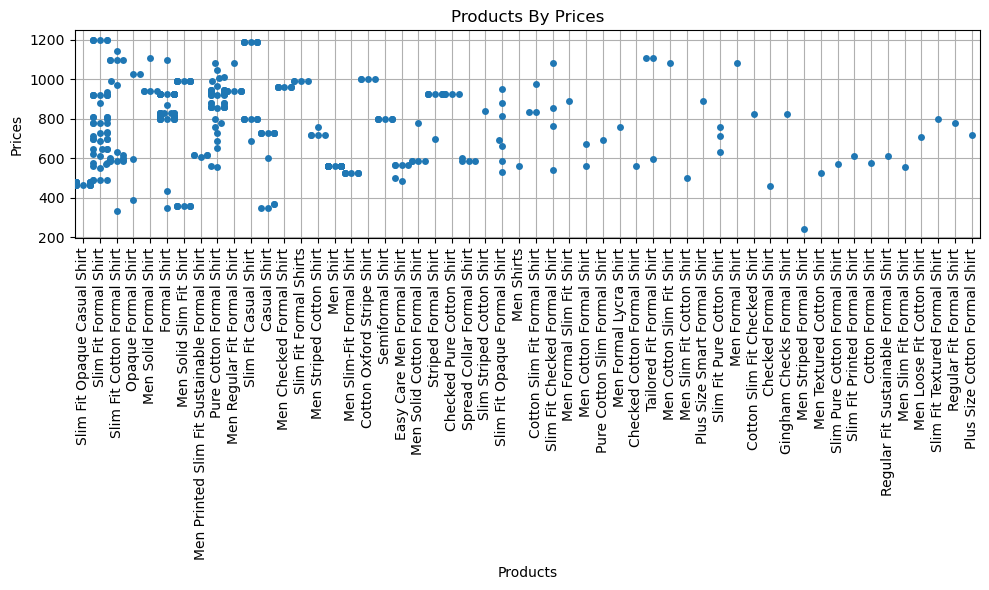

In [146]:
plt.figure(figsize=(10,6))

sns.swarmplot(data= df,x= 'Products',y = 'Prices')
plt.xticks(rotation = 90)

plt.title("Products By Prices")

plt.tight_layout()
plt.grid(True)

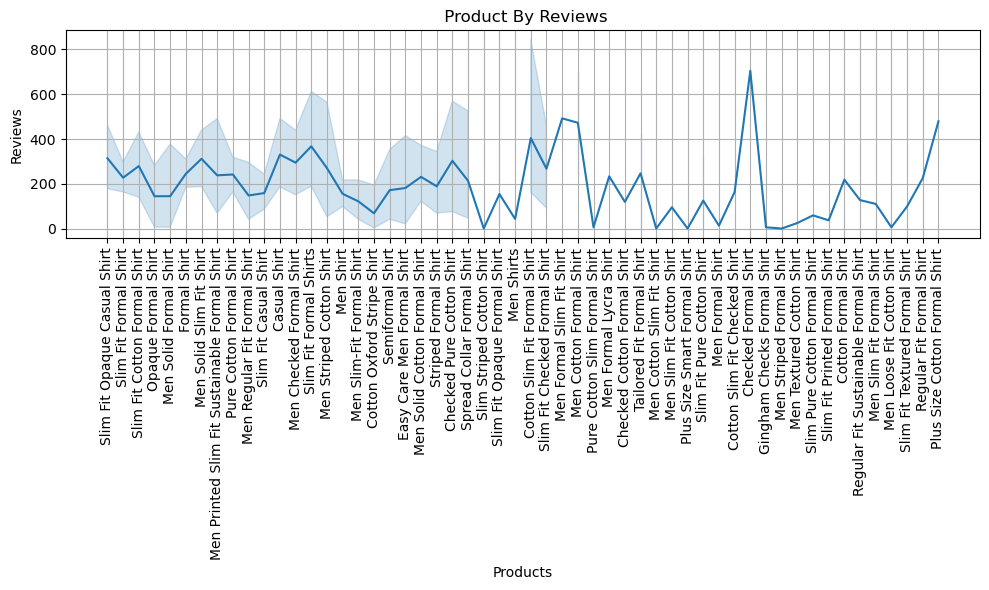

In [147]:
plt.figure(figsize=(10,6))

sns.lineplot(data= df,x= 'Products',y = 'Reviews')
plt.xticks(rotation = 90)

plt.title(" Product By Reviews")

plt.tight_layout()
plt.grid(True)

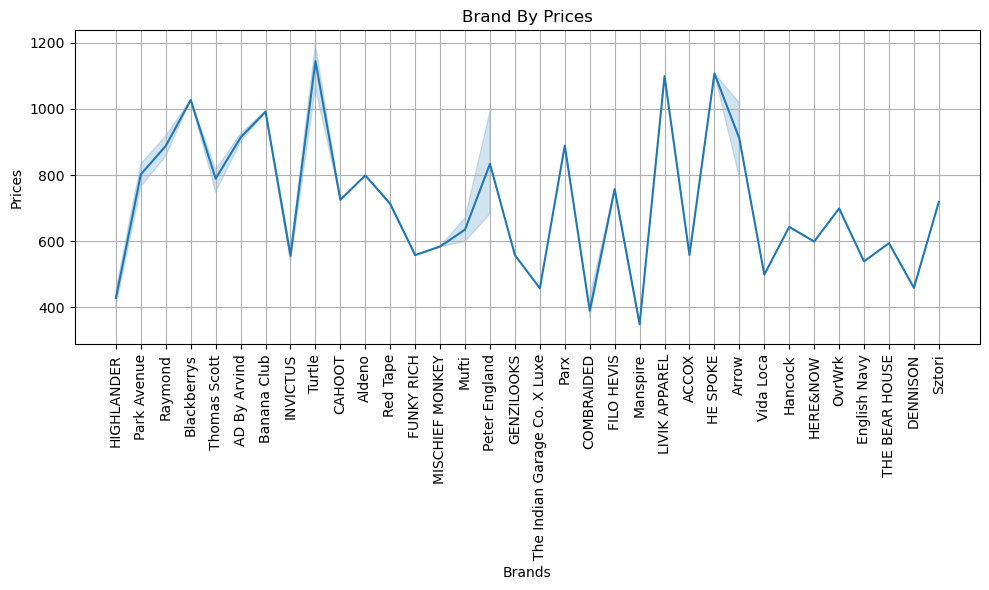

In [148]:
plt.figure(figsize=(10,6))

sns.lineplot(data= df,x= 'Brands',y = 'Prices')
plt.xticks(rotation = 90)

plt.title("Brand By Prices")

plt.tight_layout()
plt.grid(True)

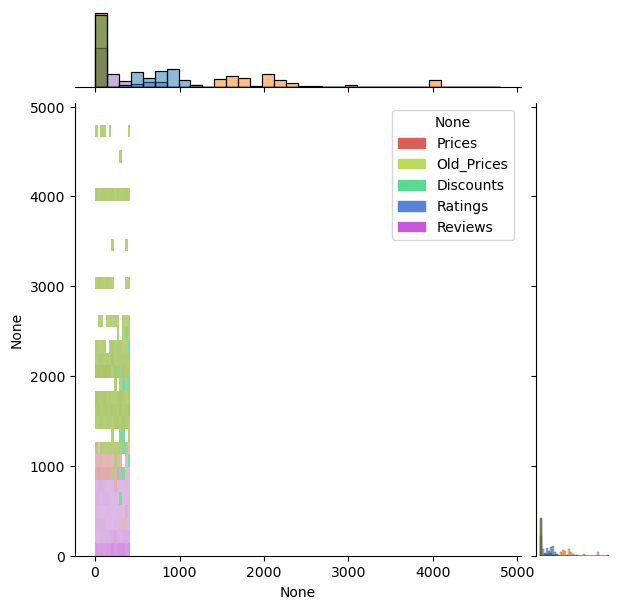

In [150]:
sns.jointplot(df, palette = 'hls', kind = 'hist' )
plt.show()

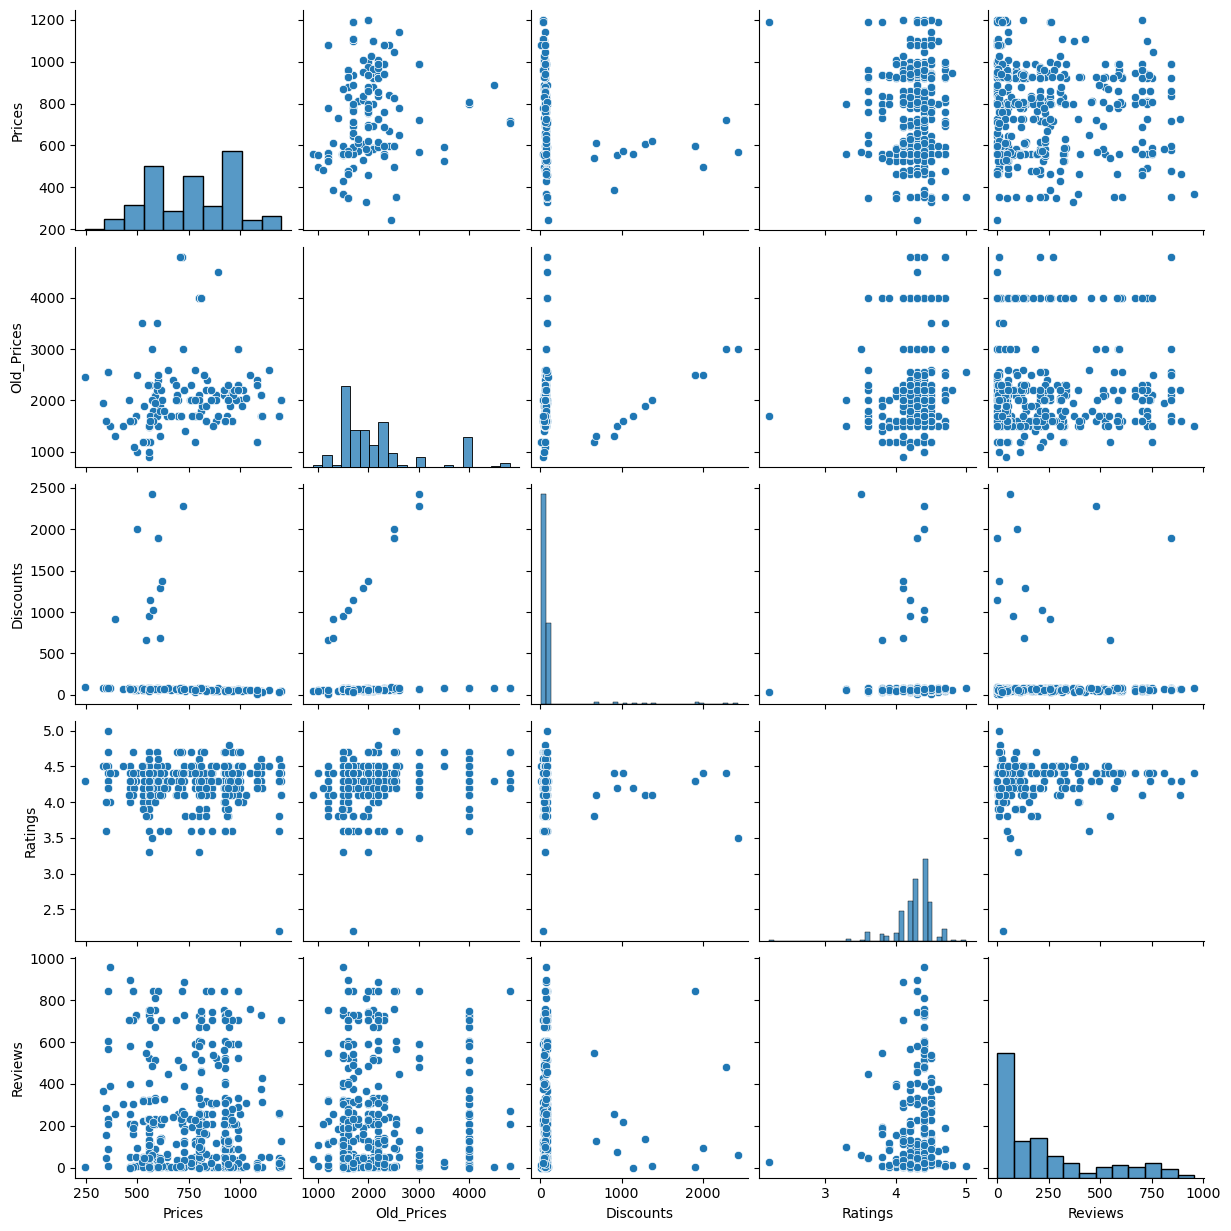

In [151]:
sns.pairplot(df)  # Displaying pairwise relationships between numerical variables

## Hypothesis Testing

In [157]:
from scipy.stats import pearsonr
from scipy.stats import f_oneway

In [158]:
corr, p_value = pearsonr(df['Prices'], df['Discounts'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: -0.17655091678213053
P-value: 0.00028158390214680015


### Interpretation

In [159]:
if p_value < 0.05:
    print("Reject H0")
else:
    print("Fail to Reject H0")

Reject H0


In [160]:
groups = [group['Ratings'].values for name, group in df.groupby('Brands')]
f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 1.0825774623031081
P-value: 0.3504362962520544


In [161]:
corr, p_value = pearsonr(df['Reviews'], df['Ratings'])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.11579113881125536
P-value: 0.017735935110999537


## Insights

* Most formal shirts are priced in the ₹500–₹1100 range.
* 50–60% discounts are the most common across products.
* Park Avenue and Raymond dominate the category with the most listings.
* Most products have ratings above 4.0, indicating good customer satisfaction.
* Slim Fit shirts are the most popular style among customers.

## Interpretation

* The project successfully analyzed Myntra shirt product data using web scraping and EDA techniques.The analysis revealed pricing trends, brand distribution, and outliers within the dataset.Most products fall under affordable and mid-range pricing categories, while only a few products belong to premium price ranges.
* Overall, pricing, discounts, brand reputation, and customer reviews are the key factors influencing purchase decisions on Myntra.